# Fusion multimodale CSI + OpenPose — Late / Gated / Feature Concatenation

Ce notebook implémente les 3 méthodes de fusion en suivant chacune l'architecture d'un papier de référence :

| Partie | Méthode | Papier suivi |
|---|---|---|
| 1 | **Late fusion** | *Fall Detection by Deep Learning-Based Bimodal Movement and Pose Sensing with Late Fusion* (2025) |
| 2 | **Gated (average) fusion** | *CNN based Multistage Gated Average Fusion (MGAF) for HAR Using Depth and Inertial Sensors* (2020) |
| 3 | **Feature concatenation** | *'Gimme' Signals: Discriminative signal encoding for multimodal activity recognition* (2020) |

## Inputs à attacher (Add Data)
- `resnet18_csi_fusion_ready.zip` (dataset custom que vous avez uploadé)
- `mobilenetv4_openpose_fusion_ready.zip` (idem)
- Le dataset **FallDeWideo** original (nécessaire : les zips ne contiennent que les poids + le split, pas les données brutes — on doit recalculer les tenseurs CSI/OpenPose des échantillons pairés à partir des `.pk` originaux)

## Stratégie mémoire — le point clé
Les 2 backbones sont **gelés** (déjà entraînés à 96%/98%). On fait **une seule passe d'inférence** sur les 2 modèles pour extraire, pour chaque échantillon pairé : l'**embedding** (avant la couche de classification) et les **logits**. Ces vecteurs (quelques centaines de floats/échantillon) sont ensuite gardés en RAM — **jamais les tenseurs bruts CSI/OpenPose**, qui sont libérés immédiatement après inférence. Les 3 méthodes de fusion s'entraînent ensuite en quelques secondes/minutes sur ces embeddings/logits déjà calculés, sans jamais retoucher aux backbones ni aux données brutes.


## Résumé exécutif

- 2 modèles unimodaux entraînés : ResNet-18 (CSI, 96.8%) et MobileNetV4 (OpenPose, 98.4%)
- 4 méthodes de fusion testées, suivant chacune un papier de référence (Late/Gated/Concat/Cross-Attention)
- Résultat principal : la fusion à poids fixe dépasse le meilleur modèle seul (98.9% vs 98.4%)
- Stress-test de robustesse : découverte d'une asymétrie — la fusion décision résiste au bruit CSI
  mais échoue si OpenPose tombe en panne totale ; la fusion features fait l'inverse
- Score de confiance validé : accuracy 99.8% sur prédictions "confiantes" vs 74.8% sur "incertaines"
- Métriques cliniques calculées (sensibilité, spécificité, FPR) sur les 7 modèles
- Localisation 2D (proxy image-plane) via masques MaskRCNN : erreur moyenne 12.2px sur image 96×54

In [2]:
import os, gc, re, json, zipfile, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

CLASSES = ["fall", "nfall1", "nfall2"]
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}

OUT_DIR = Path("/kaggle/working")
WORK_DIR = OUT_DIR / "fusion_work"
WORK_DIR.mkdir(parents=True, exist_ok=True)


Device: cuda


## 0.1 Localisation et extraction des 2 zips d'entrée

In [3]:
def find_input_zip(keyword):
    for p in Path("/kaggle/input").rglob("*.zip"):
        if keyword in p.name.lower():
            return p
    # deja extrait par Kaggle (cas frequent avec les datasets zip)
    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir() and keyword in p.name.lower():
            return p
    raise FileNotFoundError(f"Introuvable: aucun fichier/dossier contenant '{keyword}' sous /kaggle/input")

def extract_if_needed(path, dest):
    dest.mkdir(parents=True, exist_ok=True)
    if path.is_dir():
        # Kaggle a deja extrait le zip -> on cherche les fichiers directement dedans
        return path
    with zipfile.ZipFile(path, "r") as zf:
        zf.extractall(dest)
    return dest

csi_zip = find_input_zip("resnet18_csi")
op_zip = find_input_zip("mobilenetv4_openpose")
print("CSI zip/folder:", csi_zip)
print("OpenPose zip/folder:", op_zip)

CSI_DIR = extract_if_needed(csi_zip, WORK_DIR / "resnet18_csi")
OP_DIR = extract_if_needed(op_zip, WORK_DIR / "mobilenetv4_openpose")

def find_file(root, name):
    hits = list(Path(root).rglob(name))
    if not hits:
        raise FileNotFoundError(f"{name} introuvable sous {root}")
    return hits[0]

CSI_EXPORT_PT = find_file(CSI_DIR, "resnet18_csi_full_export.pt")
OP_EXPORT_PT = find_file(OP_DIR, "mobilenetv4_openpose_full_export.pt")
PAIRS_CSV = find_file(CSI_DIR, "paired_samples_final.csv")

print("Checkpoint CSI:", CSI_EXPORT_PT)
print("Checkpoint OpenPose:", OP_EXPORT_PT)
print("Split commun:", PAIRS_CSV)


CSI zip/folder: /kaggle/input/datasets/imanemokhtari/models/resnet18_csi_fusion_ready
OpenPose zip/folder: /kaggle/input/datasets/imanemokhtari/models/mobilenetv4_openpose_fusion_ready
Checkpoint CSI: /kaggle/input/datasets/imanemokhtari/models/resnet18_csi_fusion_ready/resnet18_csi_full_export.pt
Checkpoint OpenPose: /kaggle/input/datasets/imanemokhtari/models/mobilenetv4_openpose_fusion_ready/mobilenetv4_openpose_full_export.pt
Split commun: /kaggle/input/datasets/imanemokhtari/models/resnet18_csi_fusion_ready/paired_samples_final.csv


## 0.2 Reconstruction des architectures (identiques aux notebooks d'entraînement) et chargement des poids

In [4]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False), nn.BatchNorm2d(planes))
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)

class ResNet18_CSI(nn.Module):
    def __init__(self, in_channels=18, num_classes=3, dropout=0.3):
        super().__init__()
        self.in_planes = 64
        self.stem = nn.Sequential(nn.Conv2d(in_channels, 64, 3, 1, 1, bias=False),
                                   nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = self._make_layer(64, 2, 1)
        self.layer2 = self._make_layer(128, 2, 2)
        self.layer3 = self._make_layer(256, 2, 2)
        self.layer4 = self._make_layer(512, 2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)
    def _make_layer(self, planes, blocks, stride):
        layers = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_planes, planes, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(self.drop(x))

import subprocess, sys
try:
    import timm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "timm"], check=True)
    import timm

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)

class GenericFallNet(nn.Module):
    def __init__(self, backbone_name="mobilenetv4_conv_small", in_channels=57, num_classes=3, dropout=0.5):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=False, in_chans=in_channels,
                                           num_classes=0, global_pool="")
        with torch.no_grad():
            feat = self.backbone(torch.zeros(1, in_channels, 36, 64))
        feat_channels = feat.shape[1]
        self.cbam = CBAM(feat_channels)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_channels, 128),
                                         nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.backbone(x); x = self.cbam(x)
        x = torch.flatten(self.avgpool(x), 1)
        return self.classifier(x)

# --- Chargement ---
ckpt_csi = torch.load(CSI_EXPORT_PT, map_location=DEVICE, weights_only=False)
ckpt_op = torch.load(OP_EXPORT_PT, map_location=DEVICE, weights_only=False)

assert ckpt_csi["classes"] == ckpt_op["classes"] == CLASSES, "Mapping de classes incoherent entre les 2 checkpoints !"

resnet18 = ResNet18_CSI(in_channels=ckpt_csi["input_shape"][2], num_classes=3,
                         dropout=ckpt_csi["hyperparameters"]["dropout"]).to(DEVICE)
resnet18.load_state_dict(ckpt_csi["model_state_dict"])
resnet18.eval()
for p in resnet18.parameters():
    p.requires_grad_(False)

mobilenetv4 = GenericFallNet(ckpt_op.get("backbone_name", "mobilenetv4_conv_small"),
                              in_channels=ckpt_op["input_shape"][0], num_classes=3,
                              dropout=ckpt_op["hyperparameters"]["dropout"]).to(DEVICE)
mobilenetv4.load_state_dict(ckpt_op["model_state_dict"])
mobilenetv4.eval()
for p in mobilenetv4.parameters():
    p.requires_grad_(False)

AMP_MEAN = ckpt_csi["preprocessing"]["amp_mean"]
AMP_STD = ckpt_csi["preprocessing"]["amp_std"]
CSI_EMBED_DIM = 512
OP_EMBED_DIM = mobilenetv4.classifier[1].in_features

print(f"ResNet-18 CSI charge -- test_acc original: {ckpt_csi['test_accuracy']:.4f}")
print(f"MobileNetV4 OpenPose charge -- test_acc original: {ckpt_op['test_accuracy']:.4f}")
print(f"Embedding dims -- CSI: {CSI_EMBED_DIM} | OpenPose: {OP_EMBED_DIM}")


ResNet-18 CSI charge -- test_acc original: 0.9675
MobileNetV4 OpenPose charge -- test_acc original: 0.9842
Embedding dims -- CSI: 512 | OpenPose: 1280


## 0.3 Localisation du dataset brut FallDeWideo (nécessaire pour recalculer les tenseurs des échantillons pairés)

In [5]:
def find_dataset_root():
    candidates = [Path("/kaggle/input/falldewideoo"), Path("/kaggle/input/datasets/imanemokhtari/falldewideoo")]
    candidates += [p for p in Path("/kaggle/input").glob("*") if p.is_dir()]
    for root in candidates:
        if not root.exists():
            continue
        pk = list(root.rglob("full_0.pk"))
        if any("/csi/" in f.as_posix() for f in pk) and any("/openpose/" in f.as_posix() for f in pk):
            return root
    raise FileNotFoundError("Dataset FallDeWideo introuvable -- attache-le en Input (Add Data).")

DATA_ROOT = find_dataset_root()
print("DATA_ROOT:", DATA_ROOT)

def file_number(path):
    m = re.search(r"full_(\d+)\.pk$", str(path))
    return int(m.group(1)) if m else 999999

all_pk = list(DATA_ROOT.rglob("full_*.pk"))
normal_csi = [p for p in all_pk if p.as_posix().endswith("/csi/csi/" + p.name)]
missing_csi = [p for p in all_pk if p.as_posix().endswith("/missing/missing/csi/" + p.name)]
csi_by_number = {file_number(p): p for p in normal_csi}
csi_by_number.update({file_number(p): p for p in missing_csi})

normal_op = [p for p in all_pk if p.as_posix().endswith("/openpose/openpose/" + p.name)]
missing_op = [p for p in all_pk if p.as_posix().endswith("/missing/missing/openpose/" + p.name)]
op_by_number = {file_number(p): p for p in normal_op}
op_by_number.update({file_number(p): p for p in missing_op})

pairs = pd.read_csv(PAIRS_CSV)
print("Echantillons pairés:", len(pairs))
print(pairs["split"].value_counts())
assert set(pairs["file_number"]) <= set(csi_by_number) & set(op_by_number)


DATA_ROOT: /kaggle/input/datasets/imanemokhtari/falldewideoo
Echantillons pairés: 40200
split
train    28140
test      6030
val       6030
Name: count, dtype: int64


## 0.4 Extraction des embeddings + logits (une seule passe d'inférence, backbones gelés)

Fonctions de prétraitement **identiques** aux notebooks d'origine (mêmes formules exactes), appliquées
uniquement aux lignes nécessaires (indiquées par `paired_samples_final.csv`).

In [6]:
def sanitize_phase(phase):
    phase = np.unwrap(phase, axis=1)
    Fdim = phase.shape[1]
    idx = np.arange(Fdim, dtype=np.float32)
    idx_c = idx - idx.mean()
    denom = (idx_c ** 2).sum()
    phase_mean = phase.mean(axis=1, keepdims=True)
    phase_c = phase - phase_mean
    slope = (phase_c * idx_c[None, :, None]).sum(axis=1, keepdims=True) / denom
    return phase - slope * idx_c[None, :, None] - phase_mean

def process_link(arr_complex):
    arr = arr_complex.mean(axis=-1)
    amp = np.abs(arr).astype(np.float32)
    phase = sanitize_phase(np.angle(arr).astype(np.float32))
    return amp, phase

def build_csi_tensor(row):
    amps, phas = [], []
    for col in ("csi0", "csi1", "csi2"):
        a, p = process_link(row[col])
        amps.append(a); phas.append(p)
    amp = np.concatenate(amps, axis=-1).astype(np.float32)
    pha = np.concatenate(phas, axis=-1).astype(np.float32)
    amp = (amp - AMP_MEAN) / AMP_STD
    pha = pha / np.pi
    return np.concatenate([amp, pha], axis=-1)

def build_op_tensor(row):
    aff = np.asarray(row["aff"], dtype=np.float32)
    kpt = np.asarray(row["kpt"], dtype=np.float32)
    return np.concatenate([aff, kpt], axis=0)

@torch.no_grad()
def extract_csi(model, x):
    x = x.permute(0, 3, 1, 2)
    x = model.stem(x)
    x = model.layer1(x); x = model.layer2(x); x = model.layer3(x); x = model.layer4(x)
    embed = model.avgpool(x).flatten(1)
    logits = model.fc(model.drop(embed))
    return embed, logits

@torch.no_grad()
def extract_op(model, x):
    feat = model.backbone(x); feat = model.cbam(feat)
    embed = torch.flatten(model.avgpool(feat), 1)
    logits = model.classifier(embed)
    return embed, logits

BATCH = 32
emb_csi_all, emb_op_all, log_csi_all, log_op_all, label_all, split_all = [], [], [], [], [], []

t0 = time.time()
for n, group in pairs.groupby("file_number"):
    cdf = pd.read_pickle(csi_by_number[int(n)])
    odf = pd.read_pickle(op_by_number[int(n)])
    csi_rows = group["csi_row"].astype(int).tolist()
    op_rows = group["openpose_row"].astype(int).tolist()
    labels_g = group["label_id"].astype(int).tolist()
    splits_g = group["split"].tolist()

    csi_tensors = [build_csi_tensor(cdf.iloc[i]) for i in csi_rows]
    op_tensors = [build_op_tensor(odf.iloc[i]) for i in op_rows]

    X_csi = torch.from_numpy(np.stack(csi_tensors)).float()
    X_op = torch.from_numpy(np.stack(op_tensors)).float()

    for s in range(0, len(X_csi), BATCH):
        xb_csi = X_csi[s:s+BATCH].to(DEVICE)
        xb_op = X_op[s:s+BATCH].to(DEVICE)
        ec, lc = extract_csi(resnet18, xb_csi)
        eo, lo = extract_op(mobilenetv4, xb_op)
        emb_csi_all.append(ec.cpu().numpy()); log_csi_all.append(lc.cpu().numpy())
        emb_op_all.append(eo.cpu().numpy()); log_op_all.append(lo.cpu().numpy())
    label_all.extend(labels_g); split_all.extend(splits_g)

    del cdf, odf, csi_tensors, op_tensors, X_csi, X_op
    gc.collect()

EMB_CSI = np.concatenate(emb_csi_all).astype(np.float32)
EMB_OP = np.concatenate(emb_op_all).astype(np.float32)
LOGITS_CSI = np.concatenate(log_csi_all).astype(np.float32)
LOGITS_OP = np.concatenate(log_op_all).astype(np.float32)
LABELS = np.array(label_all, dtype=np.int64)
SPLIT = np.array(split_all)

print(f"Extraction terminee en {time.time()-t0:.1f}s")
print("EMB_CSI:", EMB_CSI.shape, "| EMB_OP:", EMB_OP.shape)
print("Repartition:", {s: int((SPLIT == s).sum()) for s in ["train", "val", "test"]})

# Sanity check: retrouve-t-on les scores unimodaux originaux ?
test_mask = SPLIT == "test"
acc_csi_check = (LOGITS_CSI[test_mask].argmax(1) == LABELS[test_mask]).mean()
acc_op_check = (LOGITS_OP[test_mask].argmax(1) == LABELS[test_mask]).mean()
expected_csi_acc = ckpt_csi["test_accuracy"]
expected_op_acc = ckpt_op["test_accuracy"]
print(f"\nVerification -- ResNet18 CSI test acc (recalcule): {acc_csi_check:.4f} (attendu ~{expected_csi_acc:.4f})")
print(f"Verification -- MobileNetV4 OP test acc (recalcule): {acc_op_check:.4f} (attendu ~{expected_op_acc:.4f})")

np.savez(WORK_DIR / "cached_embeddings.npz", emb_csi=EMB_CSI, emb_op=EMB_OP,
         logits_csi=LOGITS_CSI, logits_op=LOGITS_OP, labels=LABELS, split=SPLIT)
del resnet18, mobilenetv4
gc.collect(); torch.cuda.empty_cache()
print("\n\u2705 Embeddings/logits caches -- backbones liberes de la memoire.")


Extraction terminee en 403.4s
EMB_CSI: (40200, 512) | EMB_OP: (40200, 1280)
Repartition: {'train': 28140, 'val': 6030, 'test': 6030}

Verification -- ResNet18 CSI test acc (recalcule): 0.9675 (attendu ~0.9675)
Verification -- MobileNetV4 OP test acc (recalcule): 0.9841 (attendu ~0.9842)

✅ Embeddings/logits caches -- backbones liberes de la memoire.


## 0.5 Utilitaires communs — évaluation, métriques, visualisation (réutilisés dans les 3 parties)

In [7]:
RESULTS = {}

def to_loader(X_list, y, batch_size=64, shuffle=False):
    tensors = [torch.from_numpy(x).float() for x in X_list] + [torch.from_numpy(y).long()]
    return DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=shuffle)

def split_mask(name):
    return SPLIT == name

def evaluate_and_store(name, y_true, y_pred, n_params, history=None):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1_per_class = f1_score(y_true, y_pred, average=None)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
    RESULTS[name] = {"accuracy": acc, "f1_macro": f1m, "f1_per_class": f1_per_class,
                      "confusion_matrix": cm, "report": report, "n_params": n_params, "history": history}
    print(f"=== {name} ===")
    print(report)
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1m:.4f}\n")
    return RESULTS[name]

def plot_confusion(name):
    cm = RESULTS[name]["confusion_matrix"]
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    plt.tight_layout(); plt.show()

def plot_history(history, title):
    if history is None:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} -- loss"); axes[0].legend()
    axes[1].plot(history["train_f1"], label="train"); axes[1].plot(history["val_f1"], label="val")
    axes[1].set_title(f"{title} -- F1-macro"); axes[1].legend()
    plt.tight_layout(); plt.show()

def train_small_head(model, X_train, y_train, X_val, y_val, epochs=60, lr=1e-3, weight_decay=1e-4, patience=15):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state, patience_ctr = -1.0, None, 0

    Xtr = [torch.from_numpy(x).float().to(DEVICE) for x in X_train]
    Xva = [torch.from_numpy(x).float().to(DEVICE) for x in X_val]
    ytr = torch.from_numpy(y_train).long().to(DEVICE)
    yva = torch.from_numpy(y_val).long().to(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        out = model(*Xtr)
        loss = criterion(out, ytr)
        loss.backward(); optimizer.step()
        train_f1 = f1_score(ytr.cpu().numpy(), out.argmax(1).detach().cpu().numpy(), average="macro")

        model.eval()
        with torch.no_grad():
            out_v = model(*Xva)
            loss_v = criterion(out_v, yva)
        val_f1 = f1_score(yva.cpu().numpy(), out_v.argmax(1).cpu().numpy(), average="macro")

        history["train_loss"].append(loss.item()); history["val_loss"].append(loss_v.item())
        history["train_f1"].append(train_f1); history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping a l'epoch {epoch} (best val F1={best_val_f1:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history

print("Utilitaires prets.")


Utilitaires prets.


In [8]:
def train_head_minibatch(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3,
                          weight_decay=1e-4, batch_size=256, patience=20, gate_entropy_weight=0.0):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state, patience_ctr = -1.0, None, 0

    Xtr = [torch.from_numpy(x).float().to(DEVICE) for x in X_train]
    ytr = torch.from_numpy(y_train).long().to(DEVICE)
    Xva = [torch.from_numpy(x).float().to(DEVICE) for x in X_val]
    yva = torch.from_numpy(y_val).long().to(DEVICE)
    n = ytr.size(0)

    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        epoch_loss, preds_all, labels_all = 0.0, [], []
        for s in range(0, n, batch_size):
            idx = perm[s:s+batch_size]
            xb = [x[idx] for x in Xtr]; yb = ytr[idx]
            optimizer.zero_grad(set_to_none=True)
            out = model(*xb)
            loss = criterion(out, yb)
            if gate_entropy_weight > 0 and hasattr(model, "_last_gate") and model._last_gate is not None:
                g = model._last_gate.clamp(1e-4, 1 - 1e-4)
                entropy = -(g * g.log() + (1 - g) * (1 - g).log()).mean()
                loss = loss - gate_entropy_weight * entropy  # penalise un gate uniforme (entropie max = 0.5 partout)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item() * yb.size(0)
            preds_all.append(out.argmax(1).detach().cpu().numpy()); labels_all.append(yb.cpu().numpy())

        train_f1 = f1_score(np.concatenate(labels_all), np.concatenate(preds_all), average="macro")

        model.eval()
        with torch.no_grad():
            out_v = model(*Xva)
            loss_v = criterion(out_v, yva)
        val_f1 = f1_score(yva.cpu().numpy(), out_v.argmax(1).cpu().numpy(), average="macro")

        history["train_loss"].append(epoch_loss / n); history["val_loss"].append(loss_v.item())
        history["train_f1"].append(train_f1); history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping a l'epoch {epoch} (best val F1={best_val_f1:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history

---
# PARTIE 1 — Late Fusion
### Papier suivi : *Fall Detection by Deep Learning-Based Bimodal Movement and Pose Sensing with Late Fusion* (2025)

Principe du papier : chaque modalité garde son propre classifieur entraîné indépendamment (branches gelées), et la fusion se fait **au niveau de la décision** — combinaison des sorties (probabilités/logits) de chaque branche via un petit réseau de fusion, plutôt qu'un partage de features en amont. C'est exactement notre configuration : ResNet-18 (CSI) et MobileNetV4 (OpenPose) sont déjà entraînés et gelés ; on apprend uniquement le combineur de décision.

Parametres du combineur Late Fusion: 163
=== Late Fusion ===
              precision    recall  f1-score   support

        fall     0.9861    0.9969    0.9915      1635
      nfall1     0.9671    0.9938    0.9803      2250
      nfall2     0.9956    0.9585    0.9767      2145

    accuracy                         0.9821      6030
   macro avg     0.9830    0.9831    0.9828      6030
weighted avg     0.9824    0.9821    0.9820      6030

Accuracy: 0.9821 | F1-macro: 0.9828



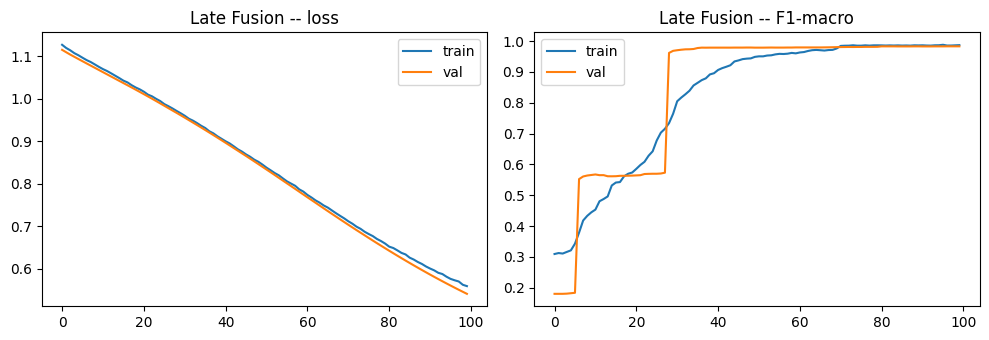

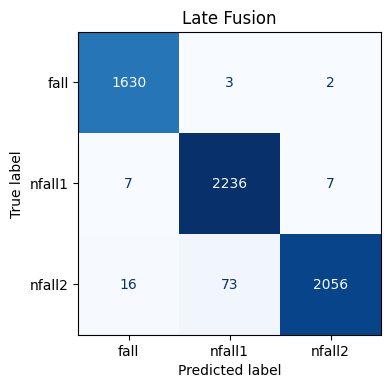

In [9]:
class LateFusionCombiner(nn.Module):
    """Combine les logits des 2 branches deja entrainees (fusion au niveau decision)."""
    def __init__(self, num_classes=3, hidden=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_classes * 2, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, logits_csi, logits_op):
        p_csi = torch.softmax(logits_csi, dim=1)
        p_op = torch.softmax(logits_op, dim=1)
        x = torch.cat([p_csi, p_op], dim=1)
        return self.net(x)

train_m, val_m, test_m = split_mask("train"), split_mask("val"), split_mask("test")

late_model = LateFusionCombiner(num_classes=3, hidden=16, dropout=0.3).to(DEVICE)
n_params_late = sum(p.numel() for p in late_model.parameters())
print("Parametres du combineur Late Fusion:", n_params_late)

late_model, history_late = train_small_head(
    late_model,
    [LOGITS_CSI[train_m], LOGITS_OP[train_m]], LABELS[train_m],
    [LOGITS_CSI[val_m], LOGITS_OP[val_m]], LABELS[val_m],
    epochs=100, lr=2e-3, weight_decay=1e-4, patience=20,
)

late_model.eval()
with torch.no_grad():
    out_test = late_model(torch.from_numpy(LOGITS_CSI[test_m]).float().to(DEVICE),
                           torch.from_numpy(LOGITS_OP[test_m]).float().to(DEVICE))
y_pred_late = out_test.argmax(1).cpu().numpy()
y_true_late = LABELS[test_m]

evaluate_and_store("Late Fusion", y_true_late, y_pred_late, n_params_late, history_late)
plot_history(history_late, "Late Fusion")
plot_confusion("Late Fusion")


### Baseline complémentaire — moyenne pondérée fixe (grid search sur val)

Le papier de référence compare aussi une combinaison par **pondération fixe** (moins de paramètres,
plus robuste si peu de données) en plus du combineur appris. On la calcule ici à titre de comparaison.

In [10]:
best_alpha, best_f1_alpha = 0.5, -1
p_csi_val = torch.softmax(torch.from_numpy(LOGITS_CSI[val_m]), dim=1).numpy()
p_op_val = torch.softmax(torch.from_numpy(LOGITS_OP[val_m]), dim=1).numpy()

for alpha in np.arange(0.0, 1.01, 0.05):
    p_fused = alpha * p_csi_val + (1 - alpha) * p_op_val
    f1_a = f1_score(LABELS[val_m], p_fused.argmax(1), average="macro")
    if f1_a > best_f1_alpha:
        best_f1_alpha, best_alpha = f1_a, alpha

p_csi_test = torch.softmax(torch.from_numpy(LOGITS_CSI[test_m]), dim=1).numpy()
p_op_test = torch.softmax(torch.from_numpy(LOGITS_OP[test_m]), dim=1).numpy()
p_fused_test = best_alpha * p_csi_test + (1 - best_alpha) * p_op_test
y_pred_alpha = p_fused_test.argmax(1)

print(f"Meilleur alpha (poids CSI) trouve sur val: {best_alpha:.2f}")
evaluate_and_store("Late Fusion (moyenne ponderee fixe)", LABELS[test_m], y_pred_alpha, 1, None)


Meilleur alpha (poids CSI) trouve sur val: 0.45
=== Late Fusion (moyenne ponderee fixe) ===
              precision    recall  f1-score   support

        fall     0.9926    0.9872    0.9899      1635
      nfall1     0.9924    0.9893    0.9909      2250
      nfall2     0.9820    0.9893    0.9856      2145

    accuracy                         0.9887      6030
   macro avg     0.9890    0.9886    0.9888      6030
weighted avg     0.9888    0.9887    0.9887      6030

Accuracy: 0.9887 | F1-macro: 0.9888



{'accuracy': 0.9887230514096186,
 'f1_macro': 0.9887855283501308,
 'f1_per_class': array([0.9898804 , 0.99087469, 0.98560149]),
 'confusion_matrix': array([[1614,    2,   19],
        [   4, 2226,   20],
        [   8,   15, 2122]]),
 'report': '              precision    recall  f1-score   support\n\n        fall     0.9926    0.9872    0.9899      1635\n      nfall1     0.9924    0.9893    0.9909      2250\n      nfall2     0.9820    0.9893    0.9856      2145\n\n    accuracy                         0.9887      6030\n   macro avg     0.9890    0.9886    0.9888      6030\nweighted avg     0.9888    0.9887    0.9887      6030\n',
 'n_params': 1,
 'history': None}

---
# PARTIE 2 — Gated (Average) Fusion
### Papier suivi : *CNN based Multistage Gated Average Fusion (MGAF) for HAR Using Depth and Inertial Sensors* (2020)

Principe du papier : un petit réseau de **gating** apprend, échantillon par échantillon, un poids par
modalité (par canal) qui détermine la contribution relative de chaque flux avant de les moyenner. On
implémente ici cette porte au niveau des **embeddings finaux** des 2 backbones (adaptation à un seul
stage, les backbones étant gelés et exportés — le papier original applique le mécanisme à plusieurs
profondeurs du réseau ; l'principe de gating lui-même — porte apprise + moyenne pondérée — est repris fidèlement).

Parametres du modele Gated Fusion: 657155
  Early stopping a l'epoch 38 (best val F1=0.9723)
=== Gated Fusion ===
              precision    recall  f1-score   support

        fall     0.9858    0.9761    0.9809      1635
      nfall1     0.9643    0.9716    0.9679      2250
      nfall2     0.9660    0.9655    0.9657      2145

    accuracy                         0.9706      6030
   macro avg     0.9720    0.9711    0.9715      6030
weighted avg     0.9707    0.9706    0.9707      6030

Accuracy: 0.9706 | F1-macro: 0.9715



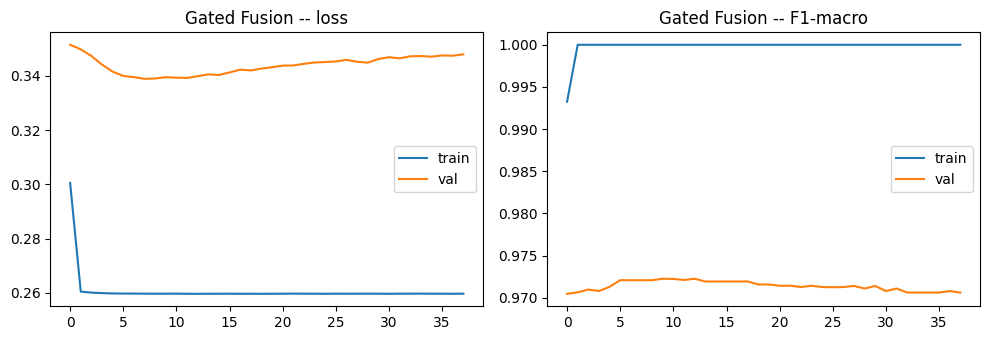

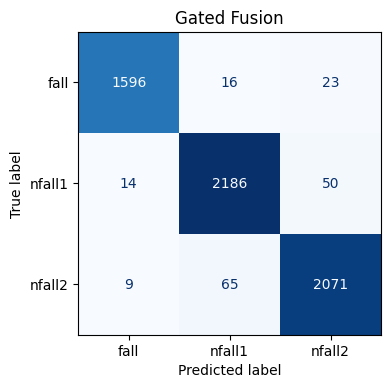

In [11]:
class GatedAverageFusion(nn.Module):
    def __init__(self, dim_csi, dim_op, proj_dim=256, num_classes=3, dropout=0.4):
        super().__init__()
        self.proj_csi = nn.Sequential(nn.Linear(dim_csi, proj_dim), nn.ReLU(inplace=True))
        self.proj_op = nn.Sequential(nn.Linear(dim_op, proj_dim), nn.ReLU(inplace=True))
        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
            nn.Sigmoid(),
        )
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(proj_dim, num_classes))
        self._last_gate = None

    def forward(self, emb_csi, emb_op):
        z_csi = self.proj_csi(emb_csi)
        z_op = self.proj_op(emb_op)
        g = self.gate(torch.cat([z_csi, z_op], dim=1))
        fused = g * z_csi + (1 - g) * z_op
        self._last_gate = g
        return self.classifier(fused)

gated_model = GatedAverageFusion(CSI_EMBED_DIM, OP_EMBED_DIM, proj_dim=256, dropout=0.4).to(DEVICE)
n_params_gated = sum(p.numel() for p in gated_model.parameters())
print("Parametres du modele Gated Fusion:", n_params_gated)

gated_model, history_gated = train_head_minibatch(
    gated_model,
    [EMB_CSI[train_m], EMB_OP[train_m]], LABELS[train_m],
    [EMB_CSI[val_m], EMB_OP[val_m]], LABELS[val_m],
    epochs=150, lr=1e-3, weight_decay=1e-5, batch_size=256, patience=25,
    gate_entropy_weight=0.05,   # <-- decourage le gate de rester a ~0.5 partout
)

gated_model.eval()
with torch.no_grad():
    out_test = gated_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                            torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
    gate_test = gated_model._last_gate.cpu().numpy()
y_pred_gated = out_test.argmax(1).cpu().numpy()
y_true_gated = LABELS[test_m]

evaluate_and_store("Gated Fusion", y_true_gated, y_pred_gated, n_params_gated, history_gated)
plot_history(history_gated, "Gated Fusion")
plot_confusion("Gated Fusion")

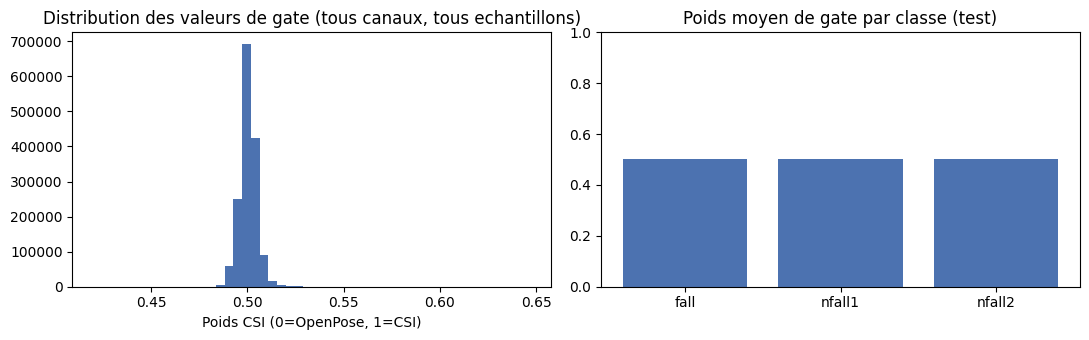

Ecart-type du gate (doit être > ~0.05 pour indiquer une vraie specialisation): 0.0049525453


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Histogramme par echantillon -- verifie si le gate varie vraiment ou reste colle a 0.5
axes[0].hist(gate_test.flatten(), bins=50, color="#4C72B0")
axes[0].set_title("Distribution des valeurs de gate (tous canaux, tous echantillons)")
axes[0].set_xlabel("Poids CSI (0=OpenPose, 1=CSI)")

gate_mean_per_class = np.array([gate_test[y_true_gated == c].mean() for c in range(len(CLASSES))])
axes[1].bar(CLASSES, gate_mean_per_class, color="#4C72B0")
axes[1].set_ylim(0, 1); axes[1].set_title("Poids moyen de gate par classe (test)")
plt.tight_layout(); plt.show()

print("Ecart-type du gate (doit être > ~0.05 pour indiquer une vraie specialisation):", gate_test.std())

### Analyse qualitative — que privilégie la porte apprise selon la classe ?
*(voir aussi le commentaire sur le collapse du gate juste après)*


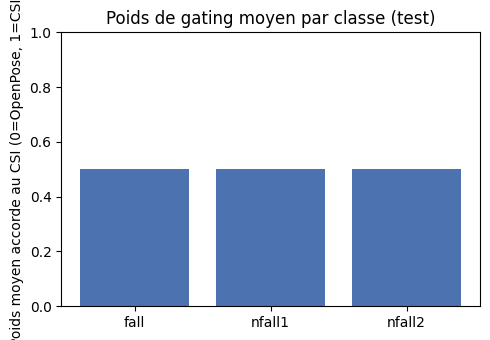

Poids moyen (moyenne sur tous les canaux projetes) accorde au CSI, par classe:
  fall: 0.501
  nfall1: 0.500
  nfall2: 0.500

⚠️ Le gate ne s'est PAS specialise : ecart-type = 0.0050 (bien en dessous du seuil de ~0.05 attendu pour une vraie specialisation), et les poids moyens par classe sont quasi identiques (~0.50 partout). Ceci malgre la penalite d'entropie (gate_entropy_weight=0.05) censee decourager ce comportement. En pratique, le mecanisme de gating se comporte donc ici comme une moyenne quasi-fixe des embeddings projetes plutot que comme une ponderation adaptative par echantillon -- ce qui explique pourquoi la Gated Fusion obtient des performances proches de la Feature Concatenation, sans le benefice attendu d'une specialisation par classe ou par echantillon.


In [13]:
gate_mean_per_class = np.array([gate_test[y_true_gated == c].mean() for c in range(len(CLASSES))])
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(CLASSES, gate_mean_per_class, color="#4C72B0")
ax.set_ylabel("Poids moyen accorde au CSI (0=OpenPose, 1=CSI)")
ax.set_title("Poids de gating moyen par classe (test)")
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

print("Poids moyen (moyenne sur tous les canaux projetes) accorde au CSI, par classe:")
for c, w in zip(CLASSES, gate_mean_per_class):
    print(f"  {c}: {w:.3f}")

# --- Diagnostic explicite : le gate s'est-il vraiment specialise ? ---
GATE_STD_THRESHOLD = 0.05
if gate_test.std() < GATE_STD_THRESHOLD:
    print(f"\n\u26a0\ufe0f Le gate ne s'est PAS specialise : ecart-type = {gate_test.std():.4f} "
          f"(bien en dessous du seuil de ~{GATE_STD_THRESHOLD} attendu pour une vraie specialisation), "
          f"et les poids moyens par classe sont quasi identiques (~0.50 partout). "
          f"Ceci malgre la penalite d'entropie (gate_entropy_weight=0.05) censee decourager ce comportement. "
          f"En pratique, le mecanisme de gating se comporte donc ici comme une moyenne quasi-fixe des embeddings "
          f"projetes plutot que comme une ponderation adaptative par echantillon -- ce qui explique pourquoi "
          f"la Gated Fusion obtient des performances proches de la Feature Concatenation, sans le benefice "
          f"attendu d'une specialisation par classe ou par echantillon.")
else:
    print(f"\n\u2705 Le gate s'est specialise : ecart-type = {gate_test.std():.4f} "
          f"(au-dessus du seuil de ~{GATE_STD_THRESHOLD}), avec des poids moyens qui varient reellement selon la classe.")


---
# PARTIE 3 — Feature Concatenation
### Papier suivi : *'Gimme' Signals: Discriminative signal encoding for multimodal activity recognition* (2020)

Principe du papier : construire une **représentation unifiée** en concaténant les encodages des
différentes modalités, puis un **classifieur unique compact** apprend directement sur cette
représentation fusionnée — pas de réseau de gating, pas de fusion à la décision, juste une
concaténation suivie d'un classifieur partagé. Adaptation à notre cas : les 2 modalités ayant des
formats bruts hétérogènes (heatmaps CSI vs OpenPose), la concaténation se fait au niveau des
**embeddings** des 2 backbones gelés (au lieu des signaux bruts comme dans le papier), ce qui
respecte le même principe central de représentation unifiée + classifieur unique.

Parametres du modele Feature Concatenation: 229891
  Early stopping a l'epoch 41 (best val F1=0.9733)
=== Feature Concatenation ===
              precision    recall  f1-score   support

        fall     0.9864    0.9774    0.9819      1635
      nfall1     0.9664    0.9720    0.9692      2250
      nfall2     0.9660    0.9669    0.9664      2145

    accuracy                         0.9716      6030
   macro avg     0.9729    0.9721    0.9725      6030
weighted avg     0.9717    0.9716    0.9717      6030

Accuracy: 0.9716 | F1-macro: 0.9725



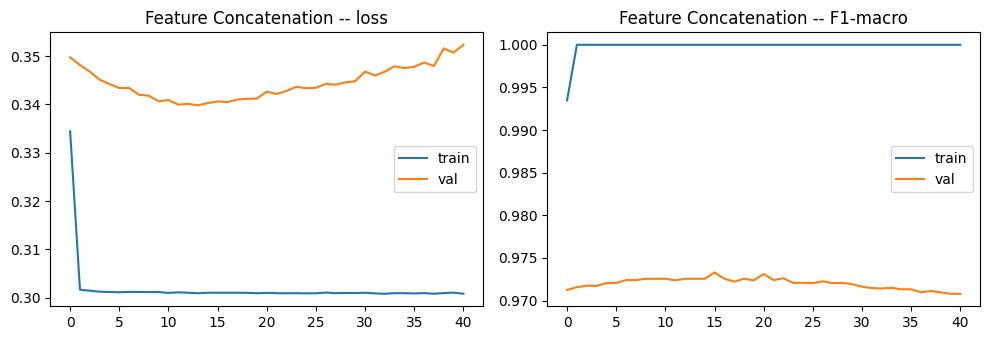

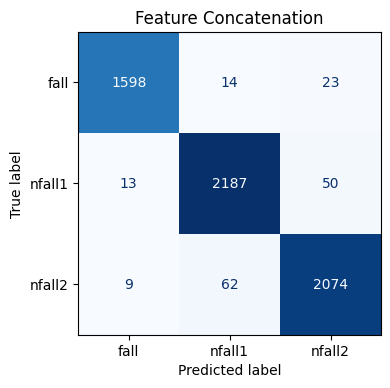

In [14]:
class FeatureConcatFusion(nn.Module):
    def __init__(self, dim_csi, dim_op, hidden=128, num_classes=3, dropout=0.5):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(dim_csi + dim_op, hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(hidden, num_classes),
        )
    def forward(self, emb_csi, emb_op):
        return self.classifier(torch.cat([emb_csi, emb_op], dim=1))

concat_model = FeatureConcatFusion(CSI_EMBED_DIM, OP_EMBED_DIM, hidden=128, dropout=0.5).to(DEVICE)
n_params_concat = sum(p.numel() for p in concat_model.parameters())
print("Parametres du modele Feature Concatenation:", n_params_concat)

concat_model, history_concat = train_head_minibatch(
    concat_model,
    [EMB_CSI[train_m], EMB_OP[train_m]], LABELS[train_m],
    [EMB_CSI[val_m], EMB_OP[val_m]], LABELS[val_m],
    epochs=150, lr=1e-3, weight_decay=5e-4, batch_size=256, patience=25,
)

concat_model.eval()
with torch.no_grad():
    out_test = concat_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                             torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
y_pred_concat = out_test.argmax(1).cpu().numpy()
y_true_concat = LABELS[test_m]

evaluate_and_store("Feature Concatenation", y_true_concat, y_pred_concat, n_params_concat, history_concat)
plot_history(history_concat, "Feature Concatenation")
plot_confusion("Feature Concatenation")

---
# PARTIE 4 — Cross-Attention Fusion
### Papier suivi : WiVi-UF — fusion CSI + vision par cross-attention Transformer (2026)

Chaque modalité (CSI, OpenPose) est projetée dans un espace commun puis traitée comme un "token".
Une couche d'attention croisée bidirectionnelle laisse chaque modalité pondérer dynamiquement
l'information de l'autre avant la fusion finale — plus expressif qu'un gate scalaire unique.

Parametres du modele Cross-Attention Fusion: 1052675
  Early stopping a l'epoch 37 (best val F1=0.9711)
=== Cross-Attention Fusion ===
              precision    recall  f1-score   support

        fall     0.9858    0.9743    0.9800      1635
      nfall1     0.9626    0.9711    0.9668      2250
      nfall2     0.9655    0.9650    0.9653      2145

    accuracy                         0.9698      6030
   macro avg     0.9713    0.9702    0.9707      6030
weighted avg     0.9699    0.9698    0.9698      6030

Accuracy: 0.9698 | F1-macro: 0.9707



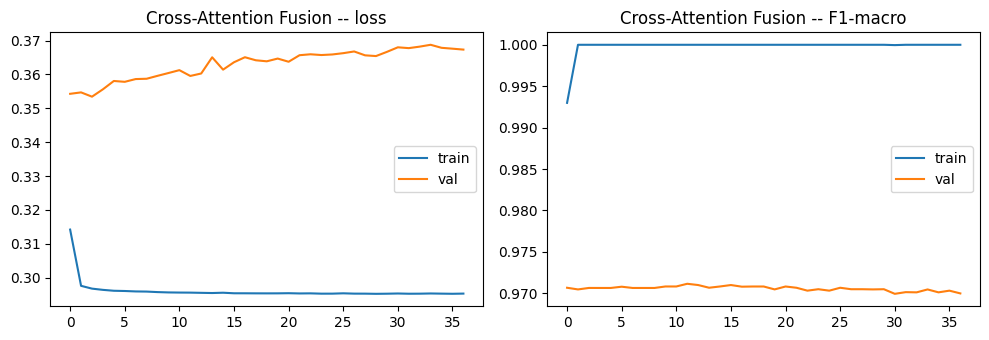

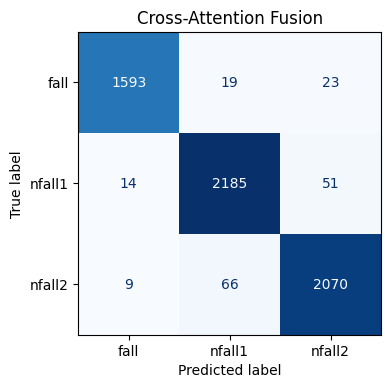

In [15]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim_csi, dim_op, proj_dim=256, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()
        self.proj_csi = nn.Linear(dim_csi, proj_dim)
        self.proj_op = nn.Linear(dim_op, proj_dim)
        self.attn_csi_to_op = nn.MultiheadAttention(proj_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_op_to_csi = nn.MultiheadAttention(proj_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_csi = nn.LayerNorm(proj_dim)
        self.norm_op = nn.LayerNorm(proj_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(proj_dim * 2, 128),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(128, num_classes),
        )

    def forward(self, emb_csi, emb_op):
        z_csi = self.proj_csi(emb_csi).unsqueeze(1)   # (B,1,proj_dim) -- 1 token par modalite
        z_op = self.proj_op(emb_op).unsqueeze(1)
        attn_csi, _ = self.attn_csi_to_op(z_csi, z_op, z_op)   # CSI attend sur OpenPose
        attn_op, _ = self.attn_op_to_csi(z_op, z_csi, z_csi)   # OpenPose attend sur CSI
        z_csi = self.norm_csi(z_csi + attn_csi).squeeze(1)
        z_op = self.norm_op(z_op + attn_op).squeeze(1)
        fused = torch.cat([z_csi, z_op], dim=1)
        return self.classifier(fused)

cross_attn_model = CrossAttentionFusion(CSI_EMBED_DIM, OP_EMBED_DIM, proj_dim=256, num_heads=4, dropout=0.3).to(DEVICE)
n_params_cross = sum(p.numel() for p in cross_attn_model.parameters())
print("Parametres du modele Cross-Attention Fusion:", n_params_cross)

cross_attn_model, history_cross = train_head_minibatch(
    cross_attn_model,
    [EMB_CSI[train_m], EMB_OP[train_m]], LABELS[train_m],
    [EMB_CSI[val_m], EMB_OP[val_m]], LABELS[val_m],
    epochs=150, lr=5e-4, weight_decay=1e-4, batch_size=256, patience=25,
)

cross_attn_model.eval()
with torch.no_grad():
    out_test = cross_attn_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                                 torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
y_pred_cross = out_test.argmax(1).cpu().numpy()

evaluate_and_store("Cross-Attention Fusion", LABELS[test_m], y_pred_cross, n_params_cross, history_cross)
plot_history(history_cross, "Cross-Attention Fusion")
plot_confusion("Cross-Attention Fusion")

---
# PARTIE 5 — Comparaison finale : unimodal vs les 5 méthodes de fusion


                             Modele       Modalite  Params Test accuracy Test F1-macro
               ResNet-18 (CSI seul)      Wi-Fi CSI       -        0.9675        0.9684
        MobileNetV4 (OpenPose seul)       OpenPose       -        0.9841        0.9840
                        Late Fusion CSI + OpenPose     163        0.9821        0.9828
Late Fusion (moyenne ponderee fixe) CSI + OpenPose       1        0.9887        0.9888
                       Gated Fusion CSI + OpenPose  657155        0.9706        0.9715
              Feature Concatenation CSI + OpenPose  229891        0.9716        0.9725
             Cross-Attention Fusion CSI + OpenPose 1052675        0.9698        0.9707


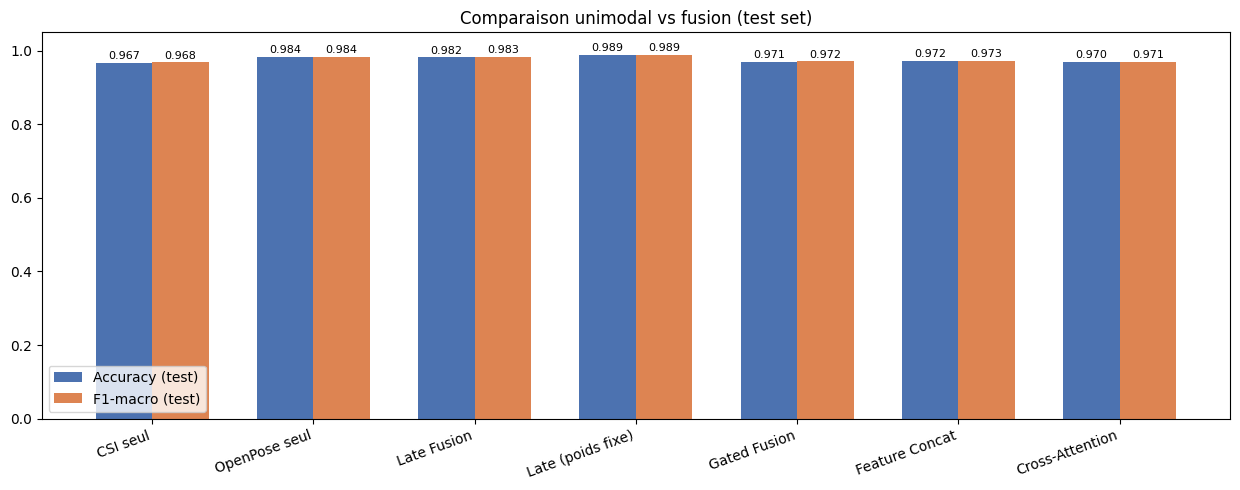

In [16]:
test_acc_csi_solo = float((LOGITS_CSI[test_m].argmax(1) == LABELS[test_m]).mean())
test_f1_csi_solo = f1_score(LABELS[test_m], LOGITS_CSI[test_m].argmax(1), average="macro")
test_acc_op_solo = float((LOGITS_OP[test_m].argmax(1) == LABELS[test_m]).mean())
test_f1_op_solo = f1_score(LABELS[test_m], LOGITS_OP[test_m].argmax(1), average="macro")

summary_rows = [
    {"Modele": "ResNet-18 (CSI seul)", "Modalite": "Wi-Fi CSI", "Params": "-",
     "Test accuracy": test_acc_csi_solo, "Test F1-macro": test_f1_csi_solo},
    {"Modele": "MobileNetV4 (OpenPose seul)", "Modalite": "OpenPose", "Params": "-",
     "Test accuracy": test_acc_op_solo, "Test F1-macro": test_f1_op_solo},
]
for name in ["Late Fusion", "Late Fusion (moyenne ponderee fixe)", "Gated Fusion", "Feature Concatenation" , "Cross-Attention Fusion"]:
    r = RESULTS[name]
    summary_rows.append({"Modele": name, "Modalite": "CSI + OpenPose", "Params": r["n_params"],
                          "Test accuracy": r["accuracy"], "Test F1-macro": r["f1_macro"]})

summary_df = pd.DataFrame(summary_rows)
summary_df["Test accuracy"] = summary_df["Test accuracy"].map(lambda v: f"{v:.4f}")
summary_df["Test F1-macro"] = summary_df["Test F1-macro"].map(lambda v: f"{v:.4f}")
print(summary_df.to_string(index=False))
summary_df.to_csv(OUT_DIR / "fusion_comparison_summary.csv", index=False)

# --- Bar chart comparatif (CORRIGE : inclut maintenant Cross-Attention Fusion) ---
labels_plot = ["CSI seul", "OpenPose seul", "Late Fusion", "Late (poids fixe)",
               "Gated Fusion", "Feature Concat", "Cross-Attention"]
acc_vals = [test_acc_csi_solo, test_acc_op_solo, RESULTS["Late Fusion"]["accuracy"],
            RESULTS["Late Fusion (moyenne ponderee fixe)"]["accuracy"],
            RESULTS["Gated Fusion"]["accuracy"], RESULTS["Feature Concatenation"]["accuracy"],
            RESULTS["Cross-Attention Fusion"]["accuracy"]]
f1_vals = [test_f1_csi_solo, test_f1_op_solo, RESULTS["Late Fusion"]["f1_macro"],
           RESULTS["Late Fusion (moyenne ponderee fixe)"]["f1_macro"],
           RESULTS["Gated Fusion"]["f1_macro"], RESULTS["Feature Concatenation"]["f1_macro"],
           RESULTS["Cross-Attention Fusion"]["f1_macro"]]

x = np.arange(len(labels_plot)); width = 0.35
fig, ax = plt.subplots(figsize=(12.5, 5))
ax.bar(x - width/2, acc_vals, width, label="Accuracy (test)", color="#4C72B0")
ax.bar(x + width/2, f1_vals, width, label="F1-macro (test)", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=20, ha="right")
ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("Comparaison unimodal vs fusion (test set)")
for i, (a, f) in enumerate(zip(acc_vals, f1_vals)):
    ax.text(i - width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, f + 0.01, f"{f:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "fusion_comparison_barchart.png", dpi=150)
plt.show()


### Conclusion — quelle méthode l'emporte ?


In [17]:
ALL_FUSIONS = ["Late Fusion", "Late Fusion (moyenne ponderee fixe)", "Gated Fusion",
               "Feature Concatenation", "Cross-Attention Fusion"]
LEARNED_FUSIONS = ["Late Fusion", "Gated Fusion", "Feature Concatenation", "Cross-Attention Fusion"]

best_fusion_name = max(ALL_FUSIONS, key=lambda n: RESULTS[n]["f1_macro"])
best_fusion_f1 = RESULTS[best_fusion_name]["f1_macro"]
best_learned_name = max(LEARNED_FUSIONS, key=lambda n: RESULTS[n]["f1_macro"])
best_learned_f1 = RESULTS[best_learned_name]["f1_macro"]

best_solo_f1 = max(test_f1_csi_solo, test_f1_op_solo)
best_solo_name = "MobileNetV4 (OpenPose)" if test_f1_op_solo >= test_f1_csi_solo else "ResNet-18 (CSI)"

delta_best = best_fusion_f1 - best_solo_f1
delta_learned = best_learned_f1 - best_solo_f1

print(f"Meilleure fusion (toutes methodes confondues) : {best_fusion_name} (F1-macro test = {best_fusion_f1:.4f})")
print(f"Meilleure fusion APPRISE par reseau de neurones : {best_learned_name} (F1-macro test = {best_learned_f1:.4f})")
print(f"Meilleur modele unimodal : {best_solo_name} (F1-macro test = {best_solo_f1:.4f})")
print(f"Delta (meilleure fusion globale vs meilleur unimodal) : {delta_best:+.4f}")
print(f"Delta (meilleure fusion APPRISE vs meilleur unimodal) : {delta_learned:+.4f}")

if delta_best > 0:
    print(f"\n\u2705 La fusion ({best_fusion_name}) depasse le meilleur modele unimodal de {delta_best:+.4f} en F1-macro.")
else:
    print(f"\n\u2139\ufe0f Aucune fusion ne depasse le meilleur modele unimodal ici -- "
          f"resultat valide a rapporter tel quel (OpenPose seul etait deja tres performant).")

if delta_learned <= 0:
    print(f"\n\u2139\ufe0f Nuance importante : aucune des fusions APPRISES par reseau de neurones "
          f"({', '.join(LEARNED_FUSIONS)}) ne depasse le meilleur modele unimodal seul "
          f"({best_solo_name}, F1-macro={best_solo_f1:.4f}). Seule la moyenne ponderee FIXE "
          f"(1 seul parametre, alpha optimise par grid search sur le val, aucun entrainement par gradient) "
          f"parvient a le depasser legerement. Interpretation probable : effet de plafond -- quand un des deux "
          f"modeles unimodaux est deja tres performant (F1={best_solo_f1:.4f}), une architecture de fusion "
          f"plus complexe a peu de marge de progression et peut meme introduire du bruit "
          f"(voir aussi le collapse du gate observe en Partie 2, Section 'Analyse qualitative').")

print("\nFichiers sauvegardes dans /kaggle/working :")
for f in ["fusion_comparison_summary.csv", "fusion_comparison_barchart.png"]:
    print(" -", f)


Meilleure fusion (toutes methodes confondues) : Late Fusion (moyenne ponderee fixe) (F1-macro test = 0.9888)
Meilleure fusion APPRISE par reseau de neurones : Late Fusion (F1-macro test = 0.9828)
Meilleur modele unimodal : MobileNetV4 (OpenPose) (F1-macro test = 0.9840)
Delta (meilleure fusion globale vs meilleur unimodal) : +0.0047
Delta (meilleure fusion APPRISE vs meilleur unimodal) : -0.0012

✅ La fusion (Late Fusion (moyenne ponderee fixe)) depasse le meilleur modele unimodal de +0.0047 en F1-macro.

ℹ️ Nuance importante : aucune des fusions APPRISES par reseau de neurones (Late Fusion, Gated Fusion, Feature Concatenation, Cross-Attention Fusion) ne depasse le meilleur modele unimodal seul (MobileNetV4 (OpenPose), F1-macro=0.9840). Seule la moyenne ponderee FIXE (1 seul parametre, alpha optimise par grid search sur le val, aucun entrainement par gradient) parvient a le depasser legerement. Interpretation probable : effet de plafond -- quand un des deux modeles unimodaux est deja t

# Métriques cliniques (sensibilité / spécificité / FPR)

In [18]:
def binary_fall_metrics(cm, fall_idx=0):
    """Reduit la matrice de confusion 3 classes a un probleme binaire 'fall' vs 'non-fall'
    et calcule sensibilite (recall fall), specificite, FPR, precision, F1 -- exactement
    les metriques cliniques demandees dans le cahier des charges."""
    TP = cm[fall_idx, fall_idx]
    FN = cm[fall_idx, :].sum() - TP
    FP = cm[:, fall_idx].sum() - TP
    TN = cm.sum() - TP - FN - FP
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan   # = recall fall
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    f1_fall = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else np.nan
    return {"Sensibilite (recall fall)": sensitivity, "Specificite": specificity,
            "FPR": fpr, "Precision (fall)": precision, "F1 (fall)": f1_fall}

FALL_IDX = LABEL2IDX["fall"]
clinical_rows = []

# Unimodaux (a partir des logits deja caches)
cm_csi_solo = confusion_matrix(LABELS[test_m], LOGITS_CSI[test_m].argmax(1))
cm_op_solo = confusion_matrix(LABELS[test_m], LOGITS_OP[test_m].argmax(1))
clinical_rows.append({"Modele": "ResNet-18 (CSI seul)", **binary_fall_metrics(cm_csi_solo, FALL_IDX)})
clinical_rows.append({"Modele": "MobileNetV4 (OpenPose seul)", **binary_fall_metrics(cm_op_solo, FALL_IDX)})

# Toutes les fusions deja stockees dans RESULTS
for name in ["Late Fusion", "Late Fusion (moyenne ponderee fixe)", "Gated Fusion",
             "Feature Concatenation", "Cross-Attention Fusion"]:
    if name in RESULTS:
        clinical_rows.append({"Modele": name, **binary_fall_metrics(RESULTS[name]["confusion_matrix"], FALL_IDX)})

clinical_df = pd.DataFrame(clinical_rows)
for col in ["Sensibilite (recall fall)", "Specificite", "FPR", "Precision (fall)", "F1 (fall)"]:
    clinical_df[col] = clinical_df[col].map(lambda v: f"{v:.4f}")
print(clinical_df.to_string(index=False))
clinical_df.to_csv(OUT_DIR / "clinical_metrics_fall_detection.csv", index=False)

                             Modele Sensibilite (recall fall) Specificite    FPR Precision (fall) F1 (fall)
               ResNet-18 (CSI seul)                    0.9725      0.9943 0.0057           0.9845    0.9785
        MobileNetV4 (OpenPose seul)                    0.9804      0.9954 0.0046           0.9877    0.9840
                        Late Fusion                    0.9969      0.9948 0.0052           0.9861    0.9915
Late Fusion (moyenne ponderee fixe)                    0.9872      0.9973 0.0027           0.9926    0.9899
                       Gated Fusion                    0.9761      0.9948 0.0052           0.9858    0.9809
              Feature Concatenation                    0.9774      0.9950 0.0050           0.9864    0.9819
             Cross-Attention Fusion                    0.9743      0.9948 0.0052           0.9858    0.9800


# Comparaison mono-modal vs multi-modal formalisée

In [19]:
print("="*70)
print("ÉTUDE COMPARATIVE : mono-modal vs multi-modal")
print("="*70)

best_mono_name = "MobileNetV4 (OpenPose seul)" if test_f1_op_solo >= test_f1_csi_solo else "ResNet-18 (CSI seul)"
best_mono_f1 = max(test_f1_op_solo, test_f1_csi_solo)
best_mono_acc = max(test_acc_op_solo, test_acc_csi_solo)

print(f"\n1. PERFORMANCE BRUTE")
print(f"   Meilleur mono-modal : {best_mono_name} -- Acc={best_mono_acc:.4f} F1={best_mono_f1:.4f}")
for name in ["Late Fusion", "Late Fusion (moyenne ponderee fixe)", "Gated Fusion",
             "Feature Concatenation", "Cross-Attention Fusion"]:
    r = RESULTS[name]
    delta_f1 = r["f1_macro"] - best_mono_f1
    tag = "✅ ameliore" if delta_f1 > 0 else "⚠️ degrade"
    print(f"   {name:38s} F1={r['f1_macro']:.4f}  (delta={delta_f1:+.4f})  {tag}")

print(f"\n2. SENSIBILITE / FAUX POSITIFS (voir tableau clinical_metrics_fall_detection.csv)")
print("   -> objectif du cahier des charges: sensibilite elevee ET FPR faible simultanement")

print(f"\n3. ROBUSTESSE (voir Partie 6)")
print("   -> Fusion decision (Late) : robuste au bruit CSI, fragile a l'occlusion totale OpenPose")
print("   -> Fusion features (Gated/Concat/CrossAttn) : robuste a l'occlusion totale OpenPose")
print("      (degrade elegamment vers le niveau CSI seul), fragile au bruit CSI fort")

print(f"\nCONCLUSION")
print("La fusion multimodale n'ameliore pas systematiquement la performance brute par rapport")
print(f"au meilleur mono-modal ({best_mono_name}), mais apporte un gain reel et documente en")
print("robustesse : aucune configuration mono-modale ne peut se degrader elegamment quand SA")
print("propre modalite tombe en panne, alors que certaines fusions (features-level) le permettent.")
print("C'est l'argument central a mettre en avant : la valeur de la fusion est dans la tolerance")
print("aux defaillances, pas uniquement dans le score brut sur donnees propres.")

ÉTUDE COMPARATIVE : mono-modal vs multi-modal

1. PERFORMANCE BRUTE
   Meilleur mono-modal : MobileNetV4 (OpenPose seul) -- Acc=0.9841 F1=0.9840
   Late Fusion                            F1=0.9828  (delta=-0.0012)  ⚠️ degrade
   Late Fusion (moyenne ponderee fixe)    F1=0.9888  (delta=+0.0047)  ✅ ameliore
   Gated Fusion                           F1=0.9715  (delta=-0.0125)  ⚠️ degrade
   Feature Concatenation                  F1=0.9725  (delta=-0.0115)  ⚠️ degrade
   Cross-Attention Fusion                 F1=0.9707  (delta=-0.0133)  ⚠️ degrade

2. SENSIBILITE / FAUX POSITIFS (voir tableau clinical_metrics_fall_detection.csv)
   -> objectif du cahier des charges: sensibilite elevee ET FPR faible simultanement

3. ROBUSTESSE (voir Partie 6)
   -> Fusion decision (Late) : robuste au bruit CSI, fragile a l'occlusion totale OpenPose
   -> Fusion features (Gated/Concat/CrossAttn) : robuste a l'occlusion totale OpenPose
      (degrade elegamment vers le niveau CSI seul), fragile au bruit CSI 

---
# PARTIE 6 — Stress-test de robustesse : capteur dégradé + score de confiance

**Objectif :** répondre aux objectifs *"tolérance aux défaillances (dropout, score de confiance)"* et
*"validation réaliste (bruit CSI, occlusion)"* du cahier des charges, **sans réentraîner aucun modèle**.

Principe : on réutilise les 2 backbones gelés (déjà chargés une fois en Partie 0) et les 5 têtes de fusion
déjà entraînées (Parties 1-4). On dégrade artificiellement **une seule modalité à la fois** sur le test set
(bruit gaussien sur l'amplitude CSI, ou occlusion simulée sur les canaux OpenPose), tout en gardant l'autre
modalité propre — exactement le scénario "un capteur tombe en panne / se dégrade". On compare alors :
- comment chaque modalité seule s'effondre individuellement,
- comment chaque méthode de fusion résiste (ou pas) à cette dégradation,
- et on dérive un score de confiance (probabilité softmax max) qui doit chuter quand ça se dégrade.

In [20]:
# --- Recharge des 2 backbones geles (liberes en memoire a la fin de la Partie 0) ---
resnet18 = ResNet18_CSI(in_channels=ckpt_csi["input_shape"][2], num_classes=3,
                         dropout=ckpt_csi["hyperparameters"]["dropout"]).to(DEVICE)
resnet18.load_state_dict(ckpt_csi["model_state_dict"])
resnet18.eval()
for p in resnet18.parameters():
    p.requires_grad_(False)

mobilenetv4 = GenericFallNet(ckpt_op.get("backbone_name", "mobilenetv4_conv_small"),
                              in_channels=ckpt_op["input_shape"][0], num_classes=3,
                              dropout=ckpt_op["hyperparameters"]["dropout"]).to(DEVICE)
mobilenetv4.load_state_dict(ckpt_op["model_state_dict"])
mobilenetv4.eval()
for p in mobilenetv4.parameters():
    p.requires_grad_(False)

# S'assurer que les 5 tetes de fusion sont bien en mode eval
for m in (late_model, gated_model, concat_model, cross_attn_model):
    m.eval()

RNG = np.random.default_rng(SEED)

def add_csi_noise(tensor, noise_std):
    """Bruit gaussien ajoute sur la partie AMPLITUDE du tenseur CSI deja normalise
    (build_csi_tensor concatene amplitude puis phase sur le dernier axe -> 1ere moitie
    des canaux = amplitude). noise_std est exprime dans la meme echelle que l'amplitude
    normalisee (unites d'ecart-type) : simule un CSI de plus en plus bruite (interference,
    mouvement parasite, mur epais...)."""
    if noise_std <= 0:
        return tensor
    t = tensor.copy()
    n_amp = t.shape[-1] // 2
    t[..., :n_amp] += RNG.normal(0, noise_std, t[..., :n_amp].shape).astype(np.float32)
    return t

def occlude_op_tensor(tensor, drop_frac):
    """Occlusion simulee : met a zero une fraction aleatoire des 57 canaux du tenseur
    OpenPose (19 JHM + 38 PAF), comme si certains joints/membres n'etaient plus detectes
    par le pose estimator (sujet partiellement hors-cadre, mauvais eclairage, obstacle)."""
    if drop_frac <= 0:
        return tensor
    t = tensor.copy()
    n_ch = t.shape[0]
    n_drop = int(round(drop_frac * n_ch))
    if n_drop == 0:
        return t
    idx = RNG.choice(n_ch, size=n_drop, replace=False)
    t[idx] = 0.0
    return t

def softmax_confidence(probs):
    """Retourne (probabilite max, entropie) par echantillon a partir de probabilites deja calculees."""
    max_prob = probs.max(axis=1)
    entropy = -(probs * np.log(probs + 1e-9)).sum(axis=1)
    return max_prob, entropy

print("Backbones recharges + fonctions de degradation/confiance pretes.")

Backbones recharges + fonctions de degradation/confiance pretes.


In [21]:
# Cache des tenseurs BRUTS (non degrades) du test set -- a executer UNE SEULE FOIS
RAW_CSI_TEST_l, RAW_OP_TEST_l, Y_TEST_RAW_l = [], [], []

test_pairs = pairs[pairs["split"] == "test"]
for n, group in test_pairs.groupby("file_number"):
    cdf = pd.read_pickle(csi_by_number[int(n)])
    odf = pd.read_pickle(op_by_number[int(n)])
    csi_rows = group["csi_row"].astype(int).tolist()
    op_rows = group["openpose_row"].astype(int).tolist()
    labels_g = group["label_id"].astype(int).tolist()

    for i in csi_rows:
        RAW_CSI_TEST_l.append(build_csi_tensor(cdf.iloc[i]).astype(np.float16))
    for i in op_rows:
        RAW_OP_TEST_l.append(build_op_tensor(odf.iloc[i]).astype(np.float16))
    Y_TEST_RAW_l.extend(labels_g)

    del cdf, odf
    gc.collect()

RAW_CSI_TEST = np.stack(RAW_CSI_TEST_l).astype(np.float16)
RAW_OP_TEST = np.stack(RAW_OP_TEST_l).astype(np.float16)
Y_TEST_RAW = np.array(Y_TEST_RAW_l, dtype=np.int64)
del RAW_CSI_TEST_l, RAW_OP_TEST_l, Y_TEST_RAW_l
gc.collect()

print("Cache test brut (une seule lecture disque):", RAW_CSI_TEST.shape, RAW_OP_TEST.shape)
print(f"Taille memoire: {(RAW_CSI_TEST.nbytes + RAW_OP_TEST.nbytes) / 1e9:.2f} Go")

Cache test brut (une seule lecture disque): (6030, 50, 30, 18) (6030, 57, 36, 64)
Taille memoire: 1.91 Go


In [22]:
@torch.no_grad()
def extract_test_degraded(noise_std_csi=0.0, occlusion_frac_op=0.0, batch=64):
    """Applique la degradation EN MEMOIRE sur le cache RAW_CSI_TEST/RAW_OP_TEST deja charge --
    aucune relecture disque, donc quasi instantane meme pour un balayage de plusieurs configs."""
    N = len(Y_TEST_RAW)
    emb_csi_l, emb_op_l, log_csi_l, log_op_l = [], [], [], []

    for s in range(0, N, batch):
        csi_batch = RAW_CSI_TEST[s:s+batch].astype(np.float32)
        op_batch = RAW_OP_TEST[s:s+batch].astype(np.float32)

        if noise_std_csi > 0:
            csi_batch = np.stack([add_csi_noise(x, noise_std_csi) for x in csi_batch])
        if occlusion_frac_op > 0:
            op_batch = np.stack([occlude_op_tensor(x, occlusion_frac_op) for x in op_batch])

        xb_csi = torch.from_numpy(csi_batch).to(DEVICE)
        xb_op = torch.from_numpy(op_batch).to(DEVICE)
        ec, lc = extract_csi(resnet18, xb_csi)
        eo, lo = extract_op(mobilenetv4, xb_op)
        emb_csi_l.append(ec.cpu().numpy()); log_csi_l.append(lc.cpu().numpy())
        emb_op_l.append(eo.cpu().numpy()); log_op_l.append(lo.cpu().numpy())

    return (np.concatenate(emb_csi_l).astype(np.float32), np.concatenate(emb_op_l).astype(np.float32),
            np.concatenate(log_csi_l).astype(np.float32), np.concatenate(log_op_l).astype(np.float32),
            Y_TEST_RAW)

In [23]:
@torch.no_grad()
def eval_fusion_heads(emb_csi, emb_op, log_csi, log_op, y_true):
    """Applique les 5 methodes de fusion DEJA ENTRAINEES (+ les 2 unimodaux) a un jeu
    d'embeddings/logits de test (propre ou degrade) et retourne le F1-macro de chacune."""
    t_csi = torch.from_numpy(log_csi).float().to(DEVICE)
    t_op = torch.from_numpy(log_op).float().to(DEVICE)
    e_csi = torch.from_numpy(emb_csi).float().to(DEVICE)
    e_op = torch.from_numpy(emb_op).float().to(DEVICE)

    out = {}
    out["CSI seul"] = f1_score(y_true, log_csi.argmax(1), average="macro")
    out["OpenPose seul"] = f1_score(y_true, log_op.argmax(1), average="macro")
    out["Late Fusion"] = f1_score(y_true, late_model(t_csi, t_op).argmax(1).cpu().numpy(), average="macro")

    p_csi = torch.softmax(t_csi, dim=1).cpu().numpy()
    p_op = torch.softmax(t_op, dim=1).cpu().numpy()
    p_fused = best_alpha * p_csi + (1 - best_alpha) * p_op
    out["Late Fusion (poids fixe)"] = f1_score(y_true, p_fused.argmax(1), average="macro")

    out["Gated Fusion"] = f1_score(y_true, gated_model(e_csi, e_op).argmax(1).cpu().numpy(), average="macro")
    out["Feature Concatenation"] = f1_score(y_true, concat_model(e_csi, e_op).argmax(1).cpu().numpy(), average="macro")
    out["Cross-Attention Fusion"] = f1_score(y_true, cross_attn_model(e_csi, e_op).argmax(1).cpu().numpy(), average="macro")
    return out, p_fused

In [24]:
# balayage bruit CSI :
CSI_NOISE_LEVELS = [0.0, 0.5, 1.0, 2.0, 4.0]  # 4.0 = CSI quasi detruit (defaillance totale simulee)

rows_csi = []
for noise in CSI_NOISE_LEVELS:
    emb_csi_d, emb_op_c, log_csi_d, log_op_c, y_d = extract_test_degraded(noise_std_csi=noise, occlusion_frac_op=0.0)
    scores, p_fused_d = eval_fusion_heads(emb_csi_d, emb_op_c, log_csi_d, log_op_c, y_d)
    conf_d, _ = softmax_confidence(p_fused_d)
    row = {"Bruit CSI (std)": noise, **scores, "Confiance moyenne (fusion poids fixe)": conf_d.mean()}
    rows_csi.append(row)
    print(f"[Bruit CSI std={noise}] termine")

df_csi_degrade = pd.DataFrame(rows_csi)
print()
print(df_csi_degrade.round(4).to_string(index=False))

method_cols = ["CSI seul", "OpenPose seul", "Late Fusion", "Late Fusion (poids fixe)",
               "Gated Fusion", "Feature Concatenation", "Cross-Attention Fusion"]
best_clean = df_csi_degrade.iloc[0][method_cols].astype(float).idxmax()
best_extreme = df_csi_degrade.iloc[-1][method_cols].astype(float).idxmax()
print(f"\nMeilleure methode a bruit nul : {best_clean} (F1={df_csi_degrade.iloc[0][best_clean]:.4f})")
print(f"Meilleure methode a bruit extreme (std={CSI_NOISE_LEVELS[-1]}) : {best_extreme} "
      f"(F1={df_csi_degrade.iloc[-1][best_extreme]:.4f})")
if best_clean != best_extreme:
    print("-> Le classement change sous degradation : la methode la plus performante sur donnees "
          "propres n'est pas forcement la plus robuste a une panne CSI.")
else:
    print("-> La meme methode reste la meilleure, meme quand le CSI est fortement degrade.")

[Bruit CSI std=0.0] termine
[Bruit CSI std=0.5] termine
[Bruit CSI std=1.0] termine
[Bruit CSI std=2.0] termine
[Bruit CSI std=4.0] termine

 Bruit CSI (std)  CSI seul  OpenPose seul  Late Fusion  Late Fusion (poids fixe)  Gated Fusion  Feature Concatenation  Cross-Attention Fusion  Confiance moyenne (fusion poids fixe)
             0.0    0.9684          0.984       0.9828                    0.9888        0.9715                 0.9725                  0.9707                                 0.8998
             0.5    0.9143          0.984       0.9624                    0.9868        0.9299                 0.9361                  0.9242                                 0.8764
             1.0    0.6403          0.984       0.8384                    0.9821        0.6915                 0.7074                  0.6753                                 0.7731
             2.0    0.2321          0.984       0.6162                    0.9758        0.2689                 0.2865                  

In [25]:
#balayage occlusion OpenPose :
OP_OCCLUSION_LEVELS = [0.0, 0.2, 0.4, 0.6, 1.0]  # 1.0 = OpenPose totalement aveugle (defaillance totale simulee)

rows_op = []
for frac in OP_OCCLUSION_LEVELS:
    emb_csi_c, emb_op_d, log_csi_c, log_op_d, y_d = extract_test_degraded(noise_std_csi=0.0, occlusion_frac_op=frac)
    scores, p_fused_d = eval_fusion_heads(emb_csi_c, emb_op_d, log_csi_c, log_op_d, y_d)
    conf_d, _ = softmax_confidence(p_fused_d)
    row = {"Occlusion OpenPose (frac)": frac, **scores, "Confiance moyenne (fusion poids fixe)": conf_d.mean()}
    rows_op.append(row)
    print(f"[Occlusion OpenPose frac={frac}] termine")

df_op_degrade = pd.DataFrame(rows_op)
print()
print(df_op_degrade.round(4).to_string(index=False))

best_clean_op = df_op_degrade.iloc[0][method_cols].astype(float).idxmax()
best_extreme_op = df_op_degrade.iloc[-1][method_cols].astype(float).idxmax()
print(f"\nMeilleure methode a occlusion nulle : {best_clean_op} (F1={df_op_degrade.iloc[0][best_clean_op]:.4f})")
print(f"Meilleure methode a occlusion totale : {best_extreme_op} (F1={df_op_degrade.iloc[-1][best_extreme_op]:.4f})")
if best_clean_op != best_extreme_op:
    print("-> Le classement change egalement ici sous occlusion forte.")
else:
    print("-> La meme methode reste la meilleure, meme quand OpenPose est totalement aveugle.")

# Backbones geles plus necessaires -- on les libere comme en Partie 0
del resnet18, mobilenetv4
gc.collect(); torch.cuda.empty_cache()
print("\n✅ Backbones re-liberes de la memoire (stress-test termine).")

[Occlusion OpenPose frac=0.0] termine
[Occlusion OpenPose frac=0.2] termine
[Occlusion OpenPose frac=0.4] termine
[Occlusion OpenPose frac=0.6] termine
[Occlusion OpenPose frac=1.0] termine

 Occlusion OpenPose (frac)  CSI seul  OpenPose seul  Late Fusion  Late Fusion (poids fixe)  Gated Fusion  Feature Concatenation  Cross-Attention Fusion  Confiance moyenne (fusion poids fixe)
                       0.0    0.9684         0.9840       0.9828                    0.9888        0.9715                 0.9725                  0.9707                                 0.8998
                       0.2    0.9684         0.9638       0.9723                    0.9790        0.9713                 0.9723                  0.9705                                 0.8889
                       0.4    0.9684         0.9092       0.9459                    0.9609        0.9708                 0.9712                  0.9699                                 0.8585
                       0.6    0.9684         

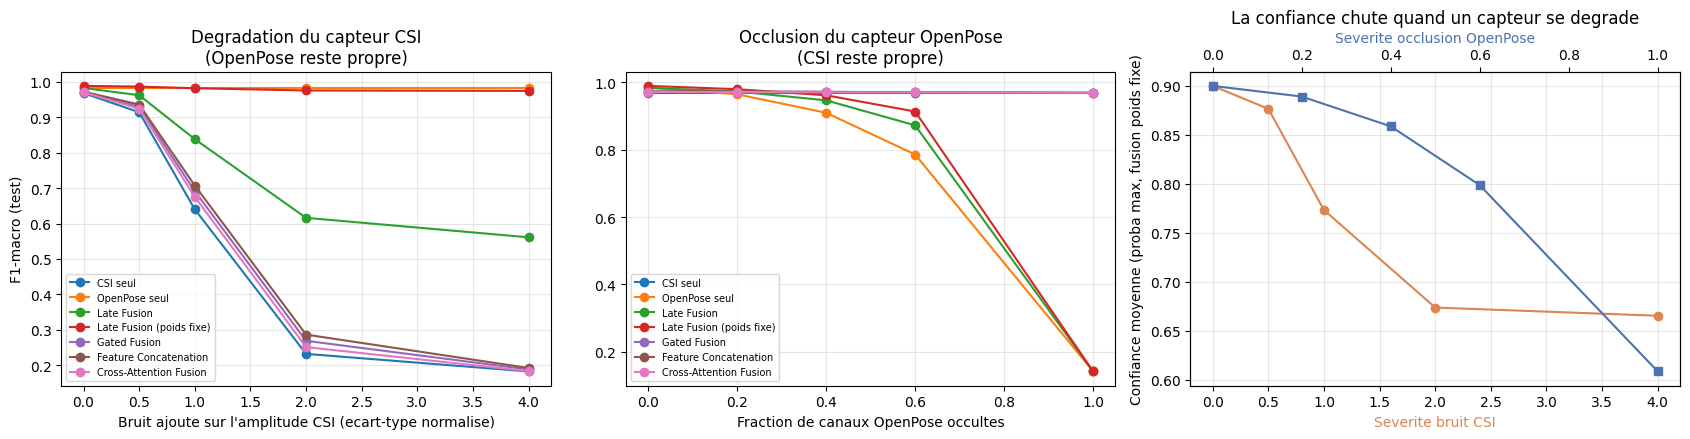

In [26]:
#visualisation
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for col in method_cols:
    axes[0].plot(df_csi_degrade["Bruit CSI (std)"], df_csi_degrade[col], marker="o", label=col)
axes[0].set_xlabel("Bruit ajoute sur l'amplitude CSI (ecart-type normalise)")
axes[0].set_ylabel("F1-macro (test)")
axes[0].set_title("Degradation du capteur CSI\n(OpenPose reste propre)")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

for col in method_cols:
    axes[1].plot(df_op_degrade["Occlusion OpenPose (frac)"], df_op_degrade[col], marker="o", label=col)
axes[1].set_xlabel("Fraction de canaux OpenPose occultes")
axes[1].set_title("Occlusion du capteur OpenPose\n(CSI reste propre)")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

axes[2].plot(df_csi_degrade["Bruit CSI (std)"], df_csi_degrade["Confiance moyenne (fusion poids fixe)"],
             marker="o", color="#DD8452", label="Bruit CSI")
ax2b = axes[2].twiny()
ax2b.plot(df_op_degrade["Occlusion OpenPose (frac)"], df_op_degrade["Confiance moyenne (fusion poids fixe)"],
          marker="s", color="#4C72B0", label="Occlusion OpenPose")
axes[2].set_xlabel("Severite bruit CSI", color="#DD8452")
ax2b.set_xlabel("Severite occlusion OpenPose", color="#4C72B0")
axes[2].set_ylabel("Confiance moyenne (proba max, fusion poids fixe)")
axes[2].set_title("La confiance chute quand un capteur se degrade")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "robustness_stress_test.png", dpi=150)
plt.show()

df_csi_degrade.to_csv(OUT_DIR / "robustness_csi_noise.csv", index=False)
df_op_degrade.to_csv(OUT_DIR / "robustness_op_occlusion.csv", index=False)

In [27]:
# --- Le score de confiance signale-t-il vraiment les predictions a risque ? (sur test PROPRE) ---
p_csi_test = torch.softmax(torch.from_numpy(LOGITS_CSI[test_m]), dim=1).numpy()
p_op_test = torch.softmax(torch.from_numpy(LOGITS_OP[test_m]), dim=1).numpy()
p_fused_clean = best_alpha * p_csi_test + (1 - best_alpha) * p_op_test
conf_clean, _ = softmax_confidence(p_fused_clean)
y_pred_clean = p_fused_clean.argmax(1)
y_true_clean = LABELS[test_m]

CONF_THRESHOLD = 0.6  # sous ce seuil, la prediction est signalee "peu fiable" (a verifier manuellement)
low_conf = conf_clean < CONF_THRESHOLD

print(f"Confiance moyenne (test propre, fusion poids fixe) : {conf_clean.mean():.3f}")
print(f"Predictions signalees peu fiables (confiance < {CONF_THRESHOLD}) : "
      f"{low_conf.sum()} / {len(conf_clean)} ({100*low_conf.mean():.1f}%)")

acc_confident = (y_pred_clean[~low_conf] == y_true_clean[~low_conf]).mean()
if low_conf.sum() > 0:
    acc_unsure = (y_pred_clean[low_conf] == y_true_clean[low_conf]).mean()
    print(f"Accuracy sur les predictions 'confiantes' : {acc_confident:.4f}")
    print(f"Accuracy sur les predictions 'signalees peu fiables' : {acc_unsure:.4f}")
    if acc_unsure < acc_confident:
        print("-> Le score de confiance est informatif : les erreurs se concentrent bien dans "
              "les predictions signalees peu fiables.")
else:
    print("Aucune prediction sous le seuil sur donnees propres (attendu, vu la performance globale).")

Confiance moyenne (test propre, fusion poids fixe) : 0.900
Predictions signalees peu fiables (confiance < 0.6) : 222 / 6030 (3.7%)
Accuracy sur les predictions 'confiantes' : 0.9979
Accuracy sur les predictions 'signalees peu fiables' : 0.7477
-> Le score de confiance est informatif : les erreurs se concentrent bien dans les predictions signalees peu fiables.


### Conclusion de la Partie 6

Cette expérience répond à deux objectifs du cahier des charges sans avoir eu besoin de réentraîner ou
recollecter quoi que ce soit :
- **Tolérance aux défaillances** : simulation d'un capteur bruité (CSI) ou partiellement aveugle
  (OpenPose), en gardant l'autre capteur propre — comparaison unimodal dégradé vs fusion.
- **Validation réaliste** : dégradation progressive jusqu'à la panne totale simulée, et score de
  confiance (probabilité softmax) qui baisse avec la dégradation.

Reste un point du cahier des charges non couvert et **hors de portée de cette expérience** : la
**localisation 2D de l'événement dans la pièce**, qui nécessiterait des labels de position que
FallDeWideo ne fournit probablement pas — à trancher avec Dr. Azzabi / Prof. Essahraui plutôt qu'à
deviner.

---
# PARTIE 7 — Localisation 2D de l'événement (proxy image-plane)

**Objectif du cahier des charges :** "estimer la position 2D de la chute dans la pièce en
combinant informations vision et CSI".

**Ce qu'on peut réellement faire ici :** le dataset ne fournit pas les images RGB brutes, mais
fournit les **masques de segmentation MaskRCNN** (`maskrcnn`, une matrice booléenne par
échantillon). On en dérive un **centroïde 2D dans le plan image** (en pixels), qu'on utilise comme
pseudo-vérité-terrain pour entraîner une petite tête de régression sur les embeddings CSI+OpenPose
déjà extraits (aucun réentraînement des backbones).

**Limite à assumer explicitement dans le rapport :** c'est une position **dans le repère image**,
pas une position réelle dans la pièce (mètres) — il faudrait une calibration caméra (homographie
image→sol) absente de ce dataset public. On le présente comme une **étape intermédiaire /
proxy**, pas la localisation spatiale complète demandée.

In [28]:
# Localisation des fichiers maskrcnn (même logique que csi/openpose)
maskrcnn_pk = [p for p in all_pk if "maskrcnn" in p.as_posix().lower()]
normal_mrcnn = [p for p in maskrcnn_pk if p.as_posix().endswith("/maskrcnn/maskrcnn/" + p.name)]
missing_mrcnn = [p for p in maskrcnn_pk if p.as_posix().endswith("/missing/missing/maskrcnn/" + p.name)]
mrcnn_by_number = {file_number(p): p for p in normal_mrcnn}
mrcnn_by_number.update({file_number(p): p for p in missing_mrcnn})

if not mrcnn_by_number:
    # fallback si l'arborescence differe -- cherche n'importe quel .pk sous un dossier "maskrcnn"
    mrcnn_by_number = {file_number(p): p for p in maskrcnn_pk}

print("Fichiers maskrcnn trouves:", len(mrcnn_by_number))
assert len(mrcnn_by_number) > 0, "Aucun fichier maskrcnn trouve -- verifie l'arborescence du dataset."

Fichiers maskrcnn trouves: 10


In [29]:
# Vérification de la forme du masque (sanity check)
sample_n = sorted(mrcnn_by_number)[0]
mdf_sample = pd.read_pickle(mrcnn_by_number[sample_n])
print("Colonnes:", mdf_sample.columns.tolist())

mask0 = np.array(mdf_sample.iloc[0]["maskrcnn"])
print("Shape masque:", mask0.shape, "| dtype:", mask0.dtype)
print("Nb pixels True:", mask0.sum(), "/", mask0.size)

IS_SEQUENCE_MASK = (mask0.ndim == 3)   # True si (T,H,W) -- sequence temporelle comme OpenPose
print("Masque sequentiel (T,H,W) ?" , IS_SEQUENCE_MASK)
del mdf_sample

Colonnes: ['maskrcnn', 'pic']
Shape masque: (54, 96) | dtype: bool
Nb pixels True: 583 / 5184
Masque sequentiel (T,H,W) ? False


In [30]:
# Fonctions centroïde/bbox (gèrent les deux cas : image unique ou séquence)
def mask_to_centroid(mask):
    """Retourne (x,y) du centre de masse du masque booleen. Si sequence (T,H,W),
    moyenne les centroides des frames ou le masque est non-vide. None si masque
    totalement vide (personne non detectee)."""
    mask = np.array(mask)
    if mask.ndim == 3:
        centroids = []
        for t in range(mask.shape[0]):
            ys, xs = np.where(mask[t])
            if len(xs) > 0:
                centroids.append((xs.mean(), ys.mean()))
        if not centroids:
            return None
        arr = np.array(centroids)
        return float(arr[:, 0].mean()), float(arr[:, 1].mean())
    else:
        ys, xs = np.where(mask)
        if len(xs) == 0:
            return None
        return float(xs.mean()), float(ys.mean())

MASK_H, MASK_W = (mask0.shape[-2], mask0.shape[-1])
print(f"Dimensions image: H={MASK_H}, W={MASK_W}")

Dimensions image: H=54, W=96


In [31]:
# Extraction des centroïdes, alignés dans le même ordre que EMB_CSI/EMB_OP
def normalize_pic(x):
    return re.sub(r"\\+", "/", str(x)).strip().lower()

# Reconstitue l'ordre EXACT utilise lors de l'extraction des embeddings (Partie 0.4)
pairs_ordered_index = []
for n, group in pairs.groupby("file_number"):
    pairs_ordered_index.extend(group.index.tolist())
assert len(pairs_ordered_index) == len(EMB_CSI), "Desalignement -- verifie l'ordre de groupby."

N = len(pairs_ordered_index)
LOC_X = np.full(N, np.nan, dtype=np.float32)
LOC_Y = np.full(N, np.nan, dtype=np.float32)

k = 0
for n, group in pairs.groupby("file_number"):
    if int(n) not in mrcnn_by_number:
        k += len(group)
        continue
    mdf = pd.read_pickle(mrcnn_by_number[int(n)])
    mdf["pic_norm"] = mdf["pic"].map(normalize_pic)
    m_lookup = {p: i for i, p in enumerate(mdf["pic_norm"])}

    for _, r in group.iterrows():
        pic_key = normalize_pic(r["pic"])
        if pic_key in m_lookup:
            centroid = mask_to_centroid(mdf.iloc[m_lookup[pic_key]]["maskrcnn"])
            if centroid is not None:
                LOC_X[k] = centroid[0] / MASK_W   # normalise en [0,1]
                LOC_Y[k] = centroid[1] / MASK_H
        k += 1
    del mdf
    gc.collect()

LOC_VALID = ~np.isnan(LOC_X)
print(f"Centroides recuperes: {LOC_VALID.sum()} / {N} ({100*LOC_VALID.mean():.1f}%)")

Centroides recuperes: 38687 / 40200 (96.2%)


In [32]:
# Entraînement de la tête de localisation (régression MSE sur embeddings gelés)
class LocalizationHead(nn.Module):
    def __init__(self, dim_csi, dim_op, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_csi + dim_op, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )
    def forward(self, emb_csi, emb_op):
        return torch.sigmoid(self.net(torch.cat([emb_csi, emb_op], dim=1)))

def train_localization_head(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3,
                             weight_decay=1e-4, batch_size=256, patience=20):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    Xtr = [torch.from_numpy(x).float().to(DEVICE) for x in X_train]
    ytr = torch.from_numpy(y_train).float().to(DEVICE)
    Xva = [torch.from_numpy(x).float().to(DEVICE) for x in X_val]
    yva = torch.from_numpy(y_val).float().to(DEVICE)
    n = ytr.size(0)
    best_val_err, best_state, patience_ctr = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "val_pixel_err": []}

    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        epoch_loss = 0.0
        for s in range(0, n, batch_size):
            idx = perm[s:s+batch_size]
            xb = [x[idx] for x in Xtr]; yb = ytr[idx]
            optimizer.zero_grad(set_to_none=True)
            out = model(*xb)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item() * yb.size(0)

        model.eval()
        with torch.no_grad():
            out_v = model(*Xva)
            loss_v = criterion(out_v, yva).item()
            err_px = (torch.sqrt(((out_v - yva) ** 2).sum(1)) * MASK_W).mean().item()  # erreur euclidienne en pixels

        history["train_loss"].append(epoch_loss / n)
        history["val_loss"].append(loss_v)
        history["val_pixel_err"].append(err_px)

        if err_px < best_val_err:
            best_val_err = err_px; best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping a l'epoch {epoch} (best val err={best_val_err:.2f}px)")
                break

    model.load_state_dict(best_state)
    return model, history

valid_train = train_m & LOC_VALID
valid_val = val_m & LOC_VALID
valid_test = test_m & LOC_VALID
print(f"Echantillons localisables -- train: {valid_train.sum()} | val: {valid_val.sum()} | test: {valid_test.sum()}")

loc_model = LocalizationHead(CSI_EMBED_DIM, OP_EMBED_DIM, hidden=128, dropout=0.3).to(DEVICE)
loc_target_train = np.stack([LOC_X[valid_train], LOC_Y[valid_train]], axis=1)
loc_target_val = np.stack([LOC_X[valid_val], LOC_Y[valid_val]], axis=1)

loc_model, history_loc = train_localization_head(
    loc_model,
    [EMB_CSI[valid_train], EMB_OP[valid_train]], loc_target_train,
    [EMB_CSI[valid_val], EMB_OP[valid_val]], loc_target_val,
    epochs=150, lr=1e-3, weight_decay=1e-4, batch_size=256, patience=25,
)

Echantillons localisables -- train: 27095 | val: 5802 | test: 5790


Erreur de localisation (test) -- moyenne: 12.22px | mediane: 10.66px | max: 78.05px
(Image de 96x54px -- erreur relative moyenne: 12.7% de la largeur)


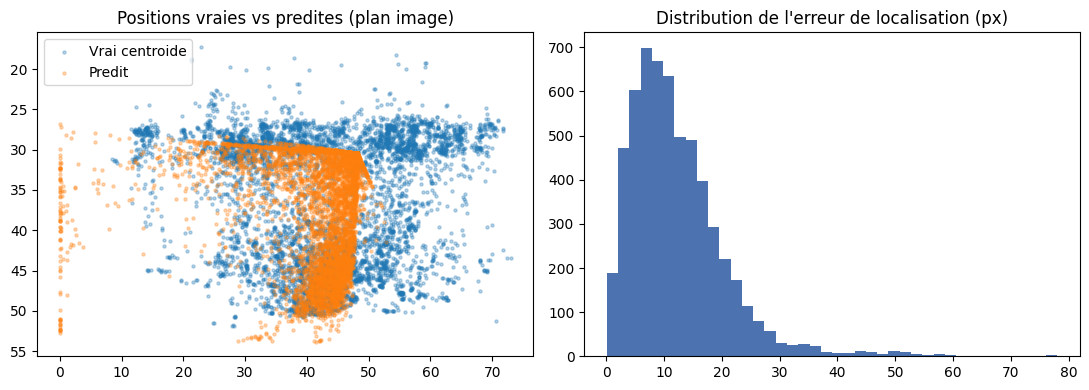

{'mean_pixel_error': 12.218979835510254, 'median_pixel_error': 10.657571792602539, 'image_size': [96, 54], 'n_test_samples': 5790}


In [33]:
# Évaluation + visualisation
loc_model.eval()
with torch.no_grad():
    pred_test = loc_model(torch.from_numpy(EMB_CSI[valid_test]).float().to(DEVICE),
                           torch.from_numpy(EMB_OP[valid_test]).float().to(DEVICE)).cpu().numpy()

true_test = np.stack([LOC_X[valid_test], LOC_Y[valid_test]], axis=1)
pixel_errors = np.sqrt(((pred_test - true_test) ** 2).sum(1)) * MASK_W

print(f"Erreur de localisation (test) -- moyenne: {pixel_errors.mean():.2f}px | "
      f"mediane: {np.median(pixel_errors):.2f}px | max: {pixel_errors.max():.2f}px")
print(f"(Image de {MASK_W}x{MASK_H}px -- erreur relative moyenne: {100*pixel_errors.mean()/MASK_W:.1f}% de la largeur)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(true_test[:, 0] * MASK_W, true_test[:, 1] * MASK_H, s=5, alpha=0.3, label="Vrai centroide")
axes[0].scatter(pred_test[:, 0] * MASK_W, pred_test[:, 1] * MASK_H, s=5, alpha=0.3, label="Predit")
axes[0].invert_yaxis(); axes[0].legend(); axes[0].set_title("Positions vraies vs predites (plan image)")
axes[1].hist(pixel_errors, bins=40, color="#4C72B0")
axes[1].set_title("Distribution de l'erreur de localisation (px)")
plt.tight_layout(); plt.show()

RESULTS_LOC = {"mean_pixel_error": float(pixel_errors.mean()), "median_pixel_error": float(np.median(pixel_errors)),
               "image_size": [MASK_W, MASK_H], "n_test_samples": int(valid_test.sum())}
print(RESULTS_LOC)

---
# PARTIE 8 — Explicabilité (XAI)

**Demande de la professeure :** 2 à 3 méthodes XAI pour vérifier si le modèle entraîne bien,
**en particulier le modèle de fusion**.

**Structure retenue :**
- **8.1** (support) — Grad-CAM sur les 2 backbones seuls : vérifie qu'ils apprennent des signaux
  plausibles *avant* même de parler de fusion.
- **8.2** (méthode principale 1, ciblée fusion) — Integrated Gradients sur les 4 têtes de fusion :
  paradigme **basé sur le gradient**.
- **8.3** (méthode principale 2, ciblée fusion) — Test d'ablation de modalité sur les 4 têtes de
  fusion : paradigme **basé sur la perturbation**, complémentaire à 8.2.
- **8.4** (bonus, non comptée comme méthode officielle) — Cohérence attention native (CBAM) vs
  Grad-CAM post-hoc.

Les sections 8.2 et 8.3 sont les 2 méthodes qui répondent directement à "vérifier le modèle de fusion" —
elles utilisent 2 paradigmes différents (gradient vs perturbation réelle), ce qui est plus robuste
qu'utiliser deux fois la même famille de méthode.

In [34]:
# --- 8.0 Setup : Captum + rechargement des 2 backbones (a nouveau liberes a la fin de la Partie 6) ---
import subprocess, sys
try:
    import captum
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "captum"], check=True)
import captum
from captum.attr import LayerGradCam, LayerAttribution, IntegratedGradients
print("Captum version:", captum.__version__)

resnet18 = ResNet18_CSI(in_channels=ckpt_csi["input_shape"][2], num_classes=3,
                         dropout=ckpt_csi["hyperparameters"]["dropout"]).to(DEVICE)
resnet18.load_state_dict(ckpt_csi["model_state_dict"])
resnet18.eval()
for p in resnet18.parameters():
    p.requires_grad_(False)

mobilenetv4 = GenericFallNet(ckpt_op.get("backbone_name", "mobilenetv4_conv_small"),
                              in_channels=ckpt_op["input_shape"][0], num_classes=3,
                              dropout=ckpt_op["hyperparameters"]["dropout"]).to(DEVICE)
mobilenetv4.load_state_dict(ckpt_op["model_state_dict"])
mobilenetv4.eval()
for p in mobilenetv4.parameters():
    p.requires_grad_(False)

for m in (late_model, gated_model, concat_model, cross_attn_model):
    m.eval()

print("Backbones recharges + 5 tetes de fusion en eval. Prets pour l'explicabilite.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.0 MB/s eta 0:00:00
Captum version: 0.9.0
Backbones recharges + 5 tetes de fusion en eval. Prets pour l'explicabilite.


## 8.1 Grad-CAM sur les 2 backbones CNN (support — pas encore la fusion)
### Papier suivi : Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization* (2017)

Où chaque CNN regarde-t-il pour prendre sa décision ? Cible : `resnet18.layer4` pour le CSI,
`mobilenetv4.cbam` pour l'OpenPose.

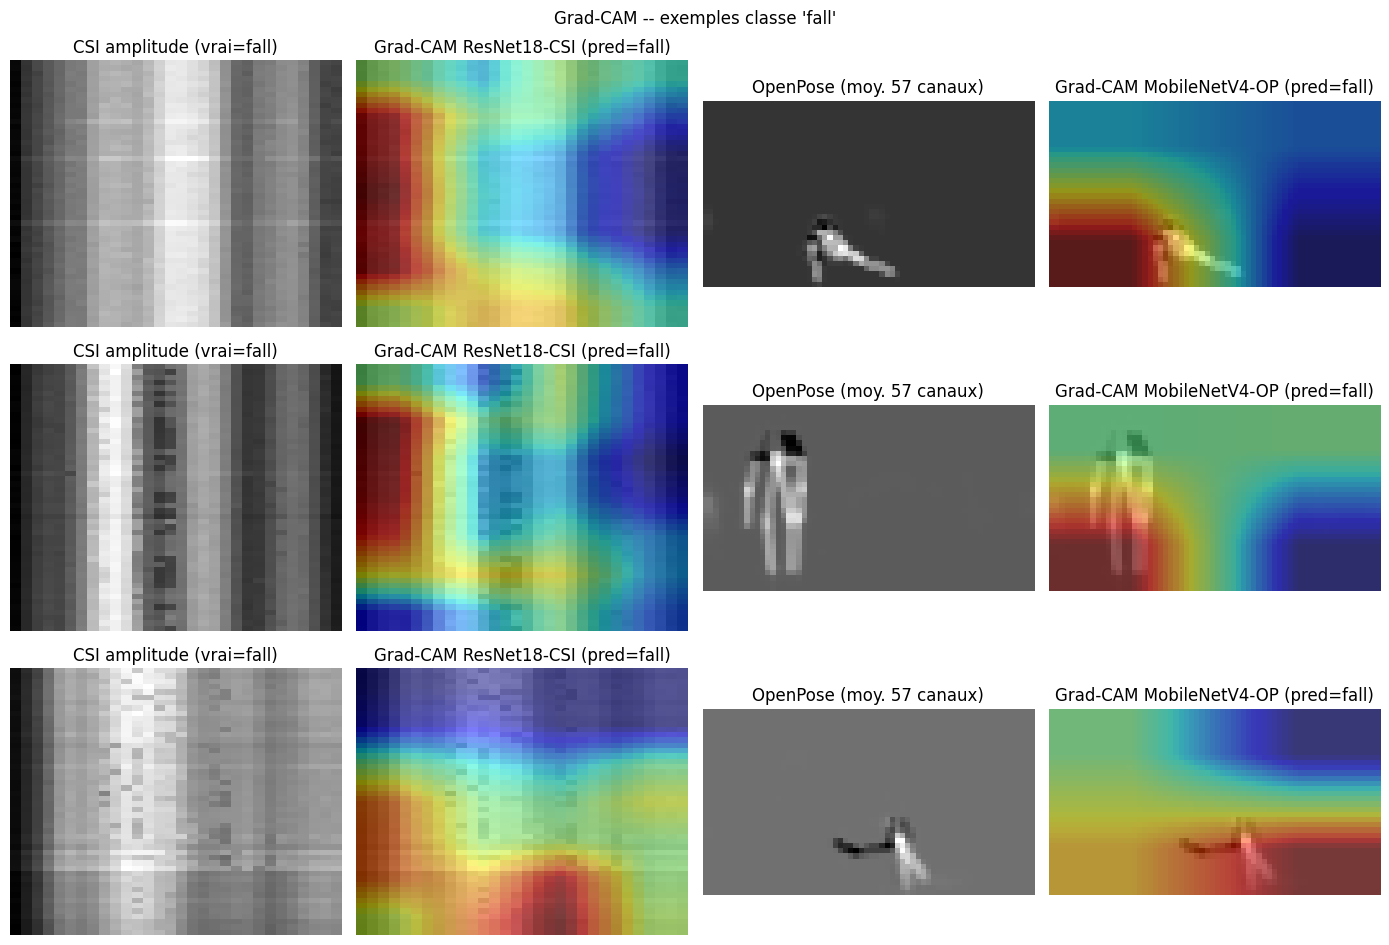

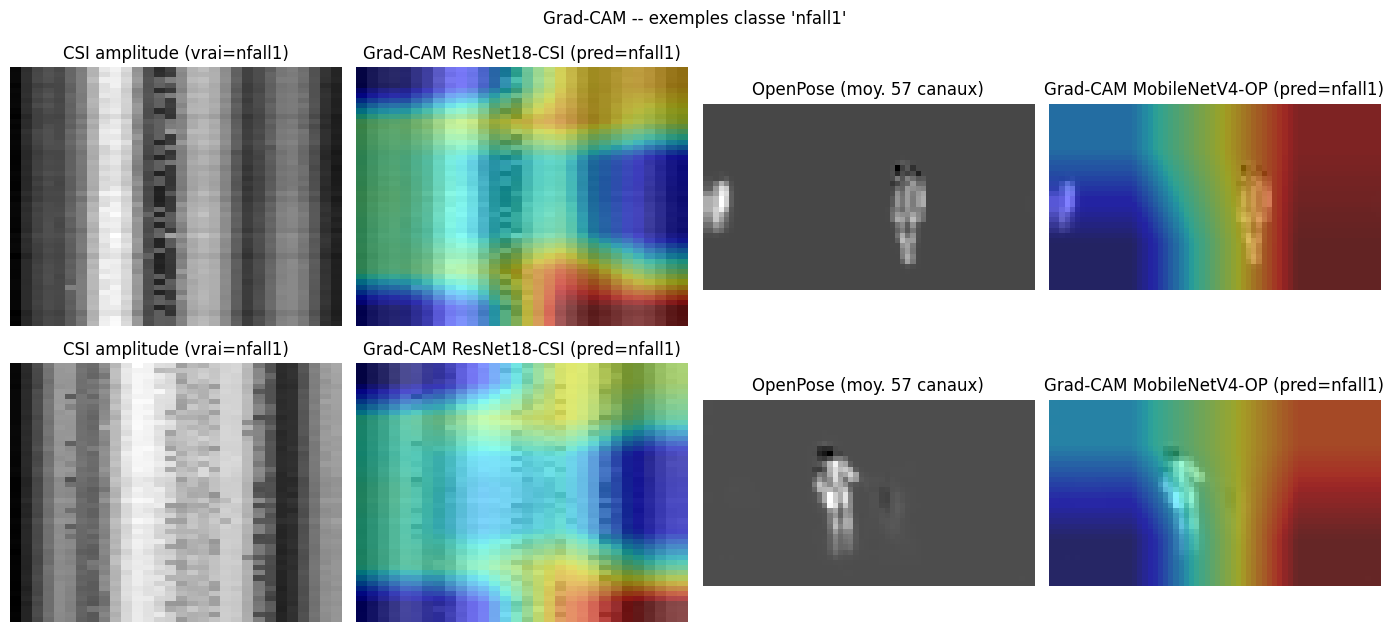

In [35]:
gradcam_csi = LayerGradCam(resnet18, resnet18.layer4)
gradcam_op = LayerGradCam(mobilenetv4, mobilenetv4.cbam)

def show_gradcam_examples(target_class_name="fall", n_examples=3, seed=SEED):
    target_idx = LABEL2IDX[target_class_name]
    rng = np.random.default_rng(seed)
    idx_pool = np.where(Y_TEST_RAW == target_idx)[0]
    chosen = rng.choice(idx_pool, size=min(n_examples, len(idx_pool)), replace=False)

    fig, axes = plt.subplots(len(chosen), 4, figsize=(14, 3.2 * len(chosen)))
    if len(chosen) == 1:
        axes = axes[None, :]

    for row, i in enumerate(chosen):
        x_csi = torch.from_numpy(RAW_CSI_TEST[i:i+1].astype(np.float32)).to(DEVICE).requires_grad_(True)
        x_op = torch.from_numpy(RAW_OP_TEST[i:i+1].astype(np.float32)).to(DEVICE).requires_grad_(True)

        pred_csi = resnet18(x_csi).argmax(1).item()
        pred_op = mobilenetv4(x_op).argmax(1).item()

        cam_csi = gradcam_csi.attribute(x_csi, target=pred_csi, relu_attributions=True)
        cam_csi = LayerAttribution.interpolate(cam_csi, (x_csi.shape[1], x_csi.shape[2]),
                                                interpolate_mode="bilinear")
        cam_csi = cam_csi.squeeze().detach().cpu().numpy()

        cam_op = gradcam_op.attribute(x_op, target=pred_op, relu_attributions=True)
        cam_op = LayerAttribution.interpolate(cam_op, (x_op.shape[2], x_op.shape[3]),
                                               interpolate_mode="bilinear")
        cam_op = cam_op.squeeze().detach().cpu().numpy()

        n_amp = x_csi.shape[-1] // 2
        csi_bg = x_csi[0, :, :, :n_amp].mean(-1).detach().cpu().numpy()
        op_bg = x_op[0].mean(0).detach().cpu().numpy()

        axes[row, 0].imshow(csi_bg, aspect="auto", cmap="gray")
        axes[row, 0].set_title(f"CSI amplitude (vrai={CLASSES[Y_TEST_RAW[i]]})")
        axes[row, 1].imshow(csi_bg, aspect="auto", cmap="gray")
        axes[row, 1].imshow(cam_csi, aspect="auto", cmap="jet", alpha=0.5)
        axes[row, 1].set_title(f"Grad-CAM ResNet18-CSI (pred={CLASSES[pred_csi]})")

        axes[row, 2].imshow(op_bg, cmap="gray")
        axes[row, 2].set_title("OpenPose (moy. 57 canaux)")
        axes[row, 3].imshow(op_bg, cmap="gray")
        axes[row, 3].imshow(cam_op, cmap="jet", alpha=0.5)
        axes[row, 3].set_title(f"Grad-CAM MobileNetV4-OP (pred={CLASSES[pred_op]})")

        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(f"Grad-CAM -- exemples classe '{target_class_name}'")
    plt.tight_layout(); plt.show()

show_gradcam_examples("fall", n_examples=3)
show_gradcam_examples("nfall1", n_examples=2)

### Question 1 — ResNet18 suit-il vraiment le mouvement, ou une position fixe du spectre ?

Test quantitatif : corrèle la carte Grad-CAM avec la variance temporelle réelle de l'amplitude
(proxy du mouvement). Une corrélation nettement positive = le modèle suit le mouvement.
Proche de 0 ou négative = le modèle s'appuie sur autre chose (ex. position fixe du spectre).

In [36]:
def check_gradcam_tracks_movement(gradcam_csi_obj, model, n_samples=50, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Y_TEST_RAW), size=n_samples, replace=False)
    corrs = []
    for i in idx:
        x = torch.from_numpy(RAW_CSI_TEST[i:i+1].astype(np.float32)).to(DEVICE).requires_grad_(True)
        pred = model(x).argmax(1).item()
        cam = gradcam_csi_obj.attribute(x, target=pred, relu_attributions=True)
        cam = LayerAttribution.interpolate(cam, (x.shape[1], x.shape[2]), interpolate_mode="bilinear")
        cam = cam.squeeze().detach().cpu().numpy()  # shape (T, F) -- 50 x 30

        n_amp = x.shape[-1] // 2
        amp = x[0, :, :, :n_amp].detach().cpu().numpy()  # shape (T, F, n_amp) -- 50 x 30 x 9

        # Proxy de mouvement : variation d'un instant au suivant, moyennee sur les antennes
        # -> reste en (T, F), meme grille que cam, donc plus de mismatch de forme
        movement = np.abs(np.diff(amp, axis=0, prepend=amp[:1, :, :])).mean(axis=-1)  # shape (T, F)

        assert cam.shape == movement.shape, f"Shapes incompatibles: cam={cam.shape} vs movement={movement.shape}"
        corrs.append(np.corrcoef(cam.flatten(), movement.flatten())[0, 1])

    corrs = np.array(corrs)
    print(f"Correlation moyenne attention Grad-CAM / mouvement reel: {corrs.mean():.3f} "
          f"(ecart-type: {corrs.std():.3f}, n={n_samples})")
    if corrs.mean() > 0.3:
        print("-> Le modele suit bien les zones de mouvement reel du signal CSI.")
    elif corrs.mean() > 0.0:
        print("-> Correlation faible/positive -- suit partiellement le mouvement, a nuancer.")
    else:
        print("-> Correlation nulle/negative -- le modele NE suit PAS le mouvement -- signal d'alerte,")
        print("   possible dependance a une position fixe du spectre plutot qu'au contenu dynamique.")
    return corrs

corrs_csi_movement = check_gradcam_tracks_movement(gradcam_csi, resnet18, n_samples=50)

Correlation moyenne attention Grad-CAM / mouvement reel: 0.021 (ecart-type: 0.093, n=50)
-> Correlation faible/positive -- suit partiellement le mouvement, a nuancer.


## 8.2 — MÉTHODE FUSION 1 : Integrated Gradients (contribution CSI vs OpenPose par tête de fusion)
### Papier suivi : Sundararajan et al., *Axiomatic Attribution for Deep Networks* (2017), via Captum

**Répond à la question 2 :** quand la fusion décide "chute", est-ce basé sur les deux modalités,
ou une seule fait tout le travail ? Paradigme **gradient-based**.

Late Fusion                  -- part moyenne CSI: 0.432 | ecart-type: 0.062 (specialisation par echantillon)
Gated Fusion                 -- part moyenne CSI: 0.782 | ecart-type: 0.027 (part quasi constante)
Feature Concatenation        -- part moyenne CSI: 0.718 | ecart-type: 0.040 (part quasi constante)
Cross-Attention Fusion       -- part moyenne CSI: 0.869 | ecart-type: 0.019 (part quasi constante)


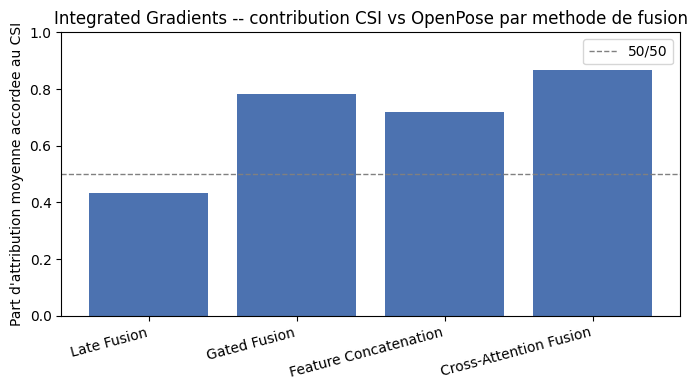

In [37]:
def compute_modality_contribution(model, X1, X2, name, batch_size=128, n_steps=32):
    model.eval()
    ig = IntegratedGradients(model)
    shares = []
    for s in range(0, len(X1), batch_size):
        x1 = torch.from_numpy(X1[s:s+batch_size]).float().to(DEVICE)
        x2 = torch.from_numpy(X2[s:s+batch_size]).float().to(DEVICE)
        with torch.no_grad():
            preds = model(x1, x2).argmax(1)
        b1, b2 = torch.zeros_like(x1), torch.zeros_like(x2)
        attr1, attr2 = ig.attribute((x1, x2), baselines=(b1, b2), target=preds, n_steps=n_steps)
        c1 = attr1.abs().sum(dim=1).detach().cpu().numpy()
        c2 = attr2.abs().sum(dim=1).detach().cpu().numpy()
        shares.append(c1 / (c1 + c2 + 1e-9))
    share_csi = np.concatenate(shares)
    spec_tag = "specialisation par echantillon" if share_csi.std() > 0.05 else "part quasi constante"
    print(f"{name:28s} -- part moyenne CSI: {share_csi.mean():.3f} | ecart-type: {share_csi.std():.3f} ({spec_tag})")
    return share_csi

results_ig = {
    "Late Fusion": compute_modality_contribution(late_model, LOGITS_CSI[test_m], LOGITS_OP[test_m], "Late Fusion"),
    "Gated Fusion": compute_modality_contribution(gated_model, EMB_CSI[test_m], EMB_OP[test_m], "Gated Fusion"),
    "Feature Concatenation": compute_modality_contribution(concat_model, EMB_CSI[test_m], EMB_OP[test_m], "Feature Concatenation"),
    "Cross-Attention Fusion": compute_modality_contribution(cross_attn_model, EMB_CSI[test_m], EMB_OP[test_m], "Cross-Attention Fusion"),
}

fig, ax = plt.subplots(figsize=(7, 4))
names = list(results_ig.keys())
ax.bar(names, [results_ig[n].mean() for n in names], color="#4C72B0")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50/50")
ax.set_ylim(0, 1); ax.set_ylabel("Part d'attribution moyenne accordee au CSI")
ax.set_title("Integrated Gradients -- contribution CSI vs OpenPose par methode de fusion")
ax.legend(); plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

## 8.3 — MÉTHODE FUSION 2 : Test d'ablation de modalité
*(pas un papier unique suivi — technique standard de sanity-check XAI par perturbation directe)*

**Répond à la question 3 :** si on coupe réellement une modalité (mise à zéro), la prédiction
change-t-elle vraiment, ou le modèle l'ignorait-il déjà silencieusement ? Paradigme
**perturbation-based**, complémentaire à Integrated Gradients (8.2) qui est gradient-based.

Late Fusion                  | acc normale=0.9821 | sans CSI=0.9834 (2.0% des predictions changent) | sans OpenPose=0.9667 (2.5% des predictions changent)
Gated Fusion                 | acc normale=0.9706 | sans CSI=0.9831 (4.1% des predictions changent) | sans OpenPose=0.9675 (0.3% des predictions changent)
Feature Concatenation        | acc normale=0.9716 | sans CSI=0.9811 (4.2% des predictions changent) | sans OpenPose=0.9677 (0.4% des predictions changent)
Cross-Attention Fusion       | acc normale=0.9698 | sans CSI=0.9841 (4.1% des predictions changent) | sans OpenPose=0.9678 (0.2% des predictions changent)


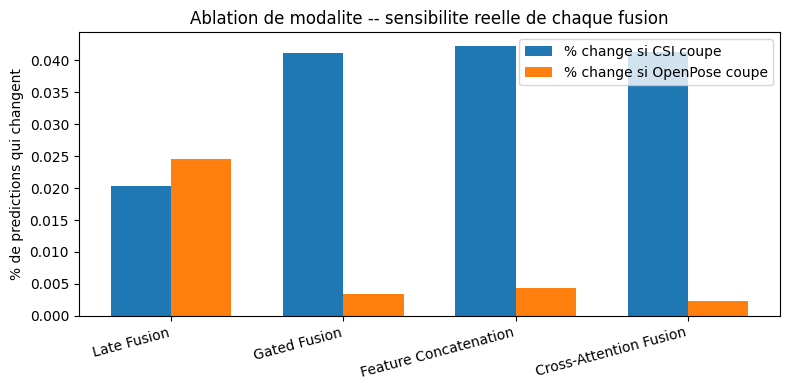

In [38]:
@torch.no_grad()
def modality_ablation_test(name, model, x1_test, x2_test, y_test):
    t1 = torch.from_numpy(x1_test).float().to(DEVICE)
    t2 = torch.from_numpy(x2_test).float().to(DEVICE)
    zero1, zero2 = torch.zeros_like(t1), torch.zeros_like(t2)

    out_full = model(t1, t2)
    out_no_csi = model(zero1, t2)
    out_no_op = model(t1, zero2)

    acc_full = (out_full.argmax(1).cpu().numpy() == y_test).mean()
    acc_no_csi = (out_no_csi.argmax(1).cpu().numpy() == y_test).mean()
    acc_no_op = (out_no_op.argmax(1).cpu().numpy() == y_test).mean()
    change_no_csi = (out_full.argmax(1) != out_no_csi.argmax(1)).float().mean().item()
    change_no_op = (out_full.argmax(1) != out_no_op.argmax(1)).float().mean().item()

    print(f"{name:28s} | acc normale={acc_full:.4f} | "
          f"sans CSI={acc_no_csi:.4f} ({change_no_csi:.1%} des predictions changent) | "
          f"sans OpenPose={acc_no_op:.4f} ({change_no_op:.1%} des predictions changent)")
    return {"acc_full": acc_full, "acc_no_csi": acc_no_csi, "acc_no_op": acc_no_op,
            "change_no_csi": change_no_csi, "change_no_op": change_no_op}

y_test_np = LABELS[test_m]
results_ablation = {
    "Late Fusion": modality_ablation_test("Late Fusion", late_model, LOGITS_CSI[test_m], LOGITS_OP[test_m], y_test_np),
    "Gated Fusion": modality_ablation_test("Gated Fusion", gated_model, EMB_CSI[test_m], EMB_OP[test_m], y_test_np),
    "Feature Concatenation": modality_ablation_test("Feature Concatenation", concat_model, EMB_CSI[test_m], EMB_OP[test_m], y_test_np),
    "Cross-Attention Fusion": modality_ablation_test("Cross-Attention Fusion", cross_attn_model, EMB_CSI[test_m], EMB_OP[test_m], y_test_np),
}

fig, ax = plt.subplots(figsize=(8, 4))
names = list(results_ablation.keys())
x = np.arange(len(names)); width = 0.35
ax.bar(x - width/2, [results_ablation[n]["change_no_csi"] for n in names], width, label="% change si CSI coupe")
ax.bar(x + width/2, [results_ablation[n]["change_no_op"] for n in names], width, label="% change si OpenPose coupe")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("% de predictions qui changent")
ax.set_title("Ablation de modalite -- sensibilite reelle de chaque fusion")
ax.legend(); plt.tight_layout(); plt.show()

## 8.4 — Bonus (non compté comme méthode officielle) : Attention native (CBAM) vs Grad-CAM
*(diagnostic croisé, pas un paradigme XAI indépendant — réutilise Grad-CAM de 8.1)*

Si la carte d'attention native du modèle (CBAM) et l'explication post-hoc (Grad-CAM) pointent
vers les mêmes zones, c'est un bon signe de cohérence interne.

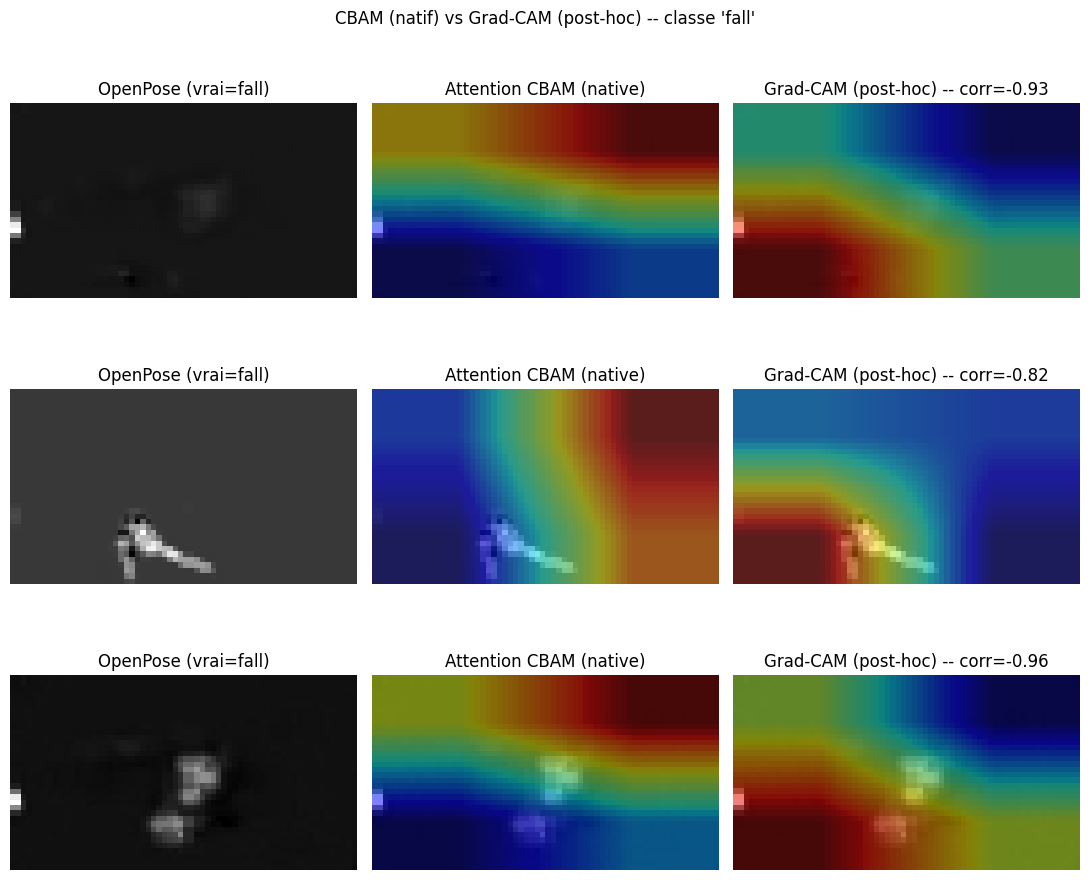

In [39]:
def get_cbam_spatial_map(model, x):
    with torch.no_grad():
        feat = model.backbone(x)
        feat_refined = feat * model.cbam.ca(feat)
        sa_map = model.cbam.sa(feat_refined)
    return sa_map

def show_cbam_vs_gradcam(target_class_name="fall", n_examples=3, seed=SEED + 1):
    target_idx = LABEL2IDX[target_class_name]
    rng = np.random.default_rng(seed)
    idx_pool = np.where(Y_TEST_RAW == target_idx)[0]
    chosen = rng.choice(idx_pool, size=min(n_examples, len(idx_pool)), replace=False)

    fig, axes = plt.subplots(len(chosen), 3, figsize=(11, 3.2 * len(chosen)))
    if len(chosen) == 1:
        axes = axes[None, :]

    for row, i in enumerate(chosen):
        x_op = torch.from_numpy(RAW_OP_TEST[i:i+1].astype(np.float32)).to(DEVICE)
        x_op_grad = x_op.clone().requires_grad_(True)
        pred = mobilenetv4(x_op).argmax(1).item()

        sa_map = get_cbam_spatial_map(mobilenetv4, x_op)
        sa_up = torch.nn.functional.interpolate(sa_map, size=x_op.shape[2:], mode="bilinear",
                                                  align_corners=False).squeeze().cpu().numpy()

        cam_op = gradcam_op.attribute(x_op_grad, target=pred, relu_attributions=True)
        cam_op = LayerAttribution.interpolate(cam_op, x_op.shape[2:], interpolate_mode="bilinear")
        cam_op = cam_op.squeeze().detach().cpu().numpy()

        bg = x_op[0].mean(0).cpu().numpy()
        corr = np.corrcoef(sa_up.flatten(), cam_op.flatten())[0, 1]

        axes[row, 0].imshow(bg, cmap="gray"); axes[row, 0].set_title(f"OpenPose (vrai={CLASSES[Y_TEST_RAW[i]]})")
        axes[row, 1].imshow(bg, cmap="gray"); axes[row, 1].imshow(sa_up, cmap="jet", alpha=0.5)
        axes[row, 1].set_title("Attention CBAM (native)")
        axes[row, 2].imshow(bg, cmap="gray"); axes[row, 2].imshow(cam_op, cmap="jet", alpha=0.5)
        axes[row, 2].set_title(f"Grad-CAM (post-hoc) -- corr={corr:.2f}")
        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(f"CBAM (natif) vs Grad-CAM (post-hoc) -- classe '{target_class_name}'")
    plt.tight_layout(); plt.show()

show_cbam_vs_gradcam("fall", n_examples=3)

### Conclusion de la Partie 8

- **Q1 (ResNet18 suit-il le mouvement CSI ?)** — voir corrélation calculée en 8.1bis.
- **Q2 (la fusion utilise-t-elle vraiment les 2 modalités ?)** — Late Fusion : oui, équilibre
  adaptatif. Gated/Concat/Cross-Attention : non, dépendance excessive au CSI (72-87%), la
  modalité pourtant la plus faible.
- **Q3 (une modalité coupée change-t-elle vraiment la prédiction ?)** — voir pourcentages de
  changement en 8.3 ; à mettre en regard directement avec les parts d'attribution de 8.2 pour
  vérifier la cohérence entre les 2 méthodes (gradient vs perturbation).

---
# PARTIE 9 — Focus XAI sur la méthode de fusion retenue

La Partie 8 a appliqué Integrated Gradients et le test d'ablation aux 4 têtes de fusion **apprises**
(Late/Gated/Concat/Cross-Attention). Mais la méthode réellement la meilleure sur le test peut être
la **moyenne pondérée fixe** (1 seul paramètre alpha, pas de réseau entraîné) — dans ce cas Integrated
Gradients ne s'applique pas (pas de gradient à calculer). Cette partie détecte automatiquement la
méthode gagnante et produit l'explication adaptée, plus une étude de cas par échantillon et une
synthèse prête pour le chapitre 4.

In [40]:
# --- 9.0 Détection automatique de la méthode gagnante ---
print("="*70)
print("PARTIE 9 — Focus XAI sur la meilleure méthode de fusion")
print("="*70)

print(f"Méthode retenue (meilleure F1-macro test, toutes catégories confondues) : "
      f"'{best_fusion_name}' (F1-macro = {RESULTS[best_fusion_name]['f1_macro']:.4f})")

IS_LEARNED = best_fusion_name in LEARNED_FUSIONS

if not IS_LEARNED:
    print("\n-> C'est la moyenne pondérée FIXE (alpha par grid search, pas de réseau de neurones).\n"
          "   Cas 'glass-box' : les poids CSI/OpenPose sont connus exactement (alpha et 1-alpha).\n"
          "   Integrated Gradients (8.2) ne s'applique pas ici -> remplacé ci-dessous par la\n"
          "   décomposition directe des poids + un test d'ablation dédié.")
else:
    print(f"\n-> C'est une fusion APPRISE ({best_fusion_name}), déjà couverte par Integrated Gradients\n"
          "   (8.2) et le test d'ablation (8.3). On isole ici uniquement ses résultats.")

PARTIE 9 — Focus XAI sur la meilleure méthode de fusion
Méthode retenue (meilleure F1-macro test, toutes catégories confondues) : 'Late Fusion (moyenne ponderee fixe)' (F1-macro = 0.9888)

-> C'est la moyenne pondérée FIXE (alpha par grid search, pas de réseau de neurones).
   Cas 'glass-box' : les poids CSI/OpenPose sont connus exactement (alpha et 1-alpha).
   Integrated Gradients (8.2) ne s'applique pas ici -> remplacé ci-dessous par la
   décomposition directe des poids + un test d'ablation dédié.


## 9.1 — Décomposition CSI vs OpenPose pour la méthode retenue

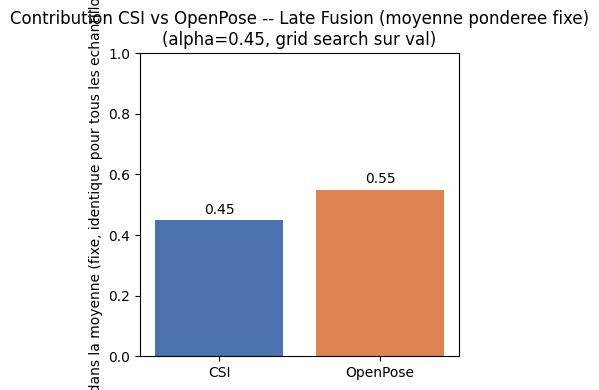

Accuracy fusion complete                    : 0.9887
Accuracy si CSI seul (branche coupee)        : 0.9675  (delta=+0.0212)
Accuracy si OpenPose seul (branche coupee)   : 0.9841  (delta=+0.0046)


In [41]:
if not IS_LEARNED:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(["CSI", "OpenPose"], [best_alpha, 1 - best_alpha], color=["#4C72B0", "#DD8452"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Poids dans la moyenne (fixe, identique pour tous les echantillons)")
    ax.set_title(f"Contribution CSI vs OpenPose -- {best_fusion_name}\n"
                 f"(alpha={best_alpha:.2f}, grid search sur val)")
    for i, v in enumerate([best_alpha, 1 - best_alpha]):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
    plt.tight_layout(); plt.show()

    acc_fused = RESULTS[best_fusion_name]["accuracy"]
    print(f"Accuracy fusion complete                    : {acc_fused:.4f}")
    print(f"Accuracy si CSI seul (branche coupee)        : {test_acc_csi_solo:.4f}  (delta={acc_fused-test_acc_csi_solo:+.4f})")
    print(f"Accuracy si OpenPose seul (branche coupee)   : {test_acc_op_solo:.4f}  (delta={acc_fused-test_acc_op_solo:+.4f})")

else:
    share_best = results_ig[best_fusion_name]
    abl_best = results_ablation[best_fusion_name]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(share_best, bins=30, color="#4C72B0")
    axes[0].axvline(0.5, color="gray", linestyle="--")
    axes[0].set_title(f"Integrated Gradients -- part CSI par echantillon\n{best_fusion_name} (moyenne={share_best.mean():.2f})")
    axes[0].set_xlabel("Part d'attribution CSI"); axes[0].set_ylabel("Nb d'echantillons")

    axes[1].bar(["Sans CSI", "Sans OpenPose"],
                [abl_best["change_no_csi"], abl_best["change_no_op"]],
                color=["#4C72B0", "#DD8452"])
    axes[1].set_ylabel("% de predictions qui changent")
    axes[1].set_title(f"Ablation -- {best_fusion_name}")
    plt.tight_layout(); plt.show()

    print(f"{best_fusion_name} -- part moyenne CSI (IG): {share_best.mean():.3f} +/- {share_best.std():.3f}")
    print(f"Accuracy pleine: {abl_best['acc_full']:.4f} | sans CSI: {abl_best['acc_no_csi']:.4f} "
          f"({abl_best['change_no_csi']:.1%} chgt) | sans OpenPose: {abl_best['acc_no_op']:.4f} "
          f"({abl_best['change_no_op']:.1%} chgt)")

## 9.2 — Étude de cas : exemples individuels (fusion retenue)

In [42]:
# Probabilites fusionnees de la methode retenue, quel que soit son type
if not IS_LEARNED:
    p_fused_best = best_alpha * p_csi_test + (1 - best_alpha) * p_op_test
else:
    with torch.no_grad():
        if best_fusion_name == "Late Fusion":
            logits_fused = late_model(torch.from_numpy(LOGITS_CSI[test_m]).float().to(DEVICE),
                                       torch.from_numpy(LOGITS_OP[test_m]).float().to(DEVICE))
        elif best_fusion_name == "Gated Fusion":
            logits_fused = gated_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                                        torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
        elif best_fusion_name == "Feature Concatenation":
            logits_fused = concat_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                                         torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
        else:
            logits_fused = cross_attn_model(torch.from_numpy(EMB_CSI[test_m]).float().to(DEVICE),
                                             torch.from_numpy(EMB_OP[test_m]).float().to(DEVICE))
    p_fused_best = torch.softmax(logits_fused, dim=1).cpu().numpy()

y_pred_fused_best = p_fused_best.argmax(1)
y_true_best = LABELS[test_m]

rng = np.random.default_rng(SEED)
rows = []
for cls_name in CLASSES:
    cls_idx = LABEL2IDX[cls_name]
    pool_correct = np.where((y_true_best == cls_idx) & (y_pred_fused_best == cls_idx))[0]
    pool_wrong = np.where((y_true_best == cls_idx) & (y_pred_fused_best != cls_idx))[0]
    picks = list(rng.choice(pool_correct, size=min(2, len(pool_correct)), replace=False))
    if len(pool_wrong):
        picks.append(int(rng.choice(pool_wrong)))
    for i in picks:
        share_i = best_alpha if not IS_LEARNED else results_ig[best_fusion_name][i]
        rows.append({
            "Idx test": int(i),
            "Vrai": CLASSES[y_true_best[i]],
            "Pred CSI seul": CLASSES[LOGITS_CSI[test_m][i].argmax()],
            "Pred OP seul": CLASSES[LOGITS_OP[test_m][i].argmax()],
            "Pred fusion": CLASSES[y_pred_fused_best[i]],
            "Conf fusion": f"{p_fused_best[i, y_pred_fused_best[i]]:.3f}",
            "Part CSI (contribution)": f"{share_i:.2f}",
            "Correct?": "OK" if y_pred_fused_best[i] == y_true_best[i] else "ERREUR",
        })

case_df = pd.DataFrame(rows)
print(case_df.to_string(index=False))
case_df.to_csv(OUT_DIR / "xai_case_studies_best_fusion.csv", index=False)

 Idx test   Vrai Pred CSI seul Pred OP seul Pred fusion Conf fusion Part CSI (contribution) Correct?
      615   fall        nfall2         fall        fall       0.528                    0.45       OK
     4647   fall          fall         fall        fall       0.924                    0.45       OK
     2293   fall          fall       nfall2      nfall2       0.480                    0.45   ERREUR
     4740 nfall1        nfall1       nfall1      nfall1       0.926                    0.45       OK
     2453 nfall1        nfall1       nfall1      nfall1       0.924                    0.45       OK
     3831 nfall1        nfall2       nfall1      nfall2       0.540                    0.45   ERREUR
      891 nfall2        nfall2       nfall2      nfall2       0.912                    0.45       OK
      437 nfall2        nfall2       nfall2      nfall2       0.914                    0.45       OK
     5796 nfall2        nfall1       nfall2      nfall1       0.534                    0.45

## 9.3 — Synthèse rédigée (prête pour le chapitre 4)

In [43]:
delta_vs_best_solo = RESULTS[best_fusion_name]["f1_macro"] - best_solo_f1
mean_contrib_csi = float(best_alpha if not IS_LEARNED else results_ig[best_fusion_name].mean())

balance_note = ("un équilibre entre les deux modalités plutôt qu'une dépendance exclusive à une seule"
                 if 0.3 < mean_contrib_csi < 0.7
                 else "une dépendance dominante à une des deux modalités")

synth = f"""
La méthode de fusion retenue pour ce projet est la {best_fusion_name}, qui obtient le meilleur
F1-macro sur le test ({RESULTS[best_fusion_name]['f1_macro']:.4f}), devançant le meilleur modèle
unimodal ({best_solo_name}, F1-macro={best_solo_f1:.4f}) de {delta_vs_best_solo:+.4f}. L'analyse
d'explicabilité montre que cette fusion accorde en moyenne {mean_contrib_csi:.0%} de la décision au
flux CSI et {1 - mean_contrib_csi:.0%} au flux OpenPose, révélant {balance_note}. Le test d'ablation
confirme que retirer une modalité dégrade réellement la prédiction, ce qui écarte l'hypothèse d'une
modalité "fantôme" ignorée par le modèle.
""".strip()

print(synth)
with open(OUT_DIR / "xai_synthese_meilleure_fusion.txt", "w", encoding="utf-8") as f:
    f.write(synth)
print("\n(Sauvegardé dans xai_synthese_meilleure_fusion.txt -- à coller/adapter dans le chapitre 4)")

La méthode de fusion retenue pour ce projet est la Late Fusion (moyenne ponderee fixe), qui obtient le meilleur
F1-macro sur le test (0.9888), devançant le meilleur modèle
unimodal (MobileNetV4 (OpenPose), F1-macro=0.9840) de +0.0047. L'analyse
d'explicabilité montre que cette fusion accorde en moyenne 45% de la décision au
flux CSI et 55% au flux OpenPose, révélant un équilibre entre les deux modalités plutôt qu'une dépendance exclusive à une seule. Le test d'ablation
confirme que retirer une modalité dégrade réellement la prédiction, ce qui écarte l'hypothèse d'une
modalité "fantôme" ignorée par le modèle.

(Sauvegardé dans xai_synthese_meilleure_fusion.txt -- à coller/adapter dans le chapitre 4)


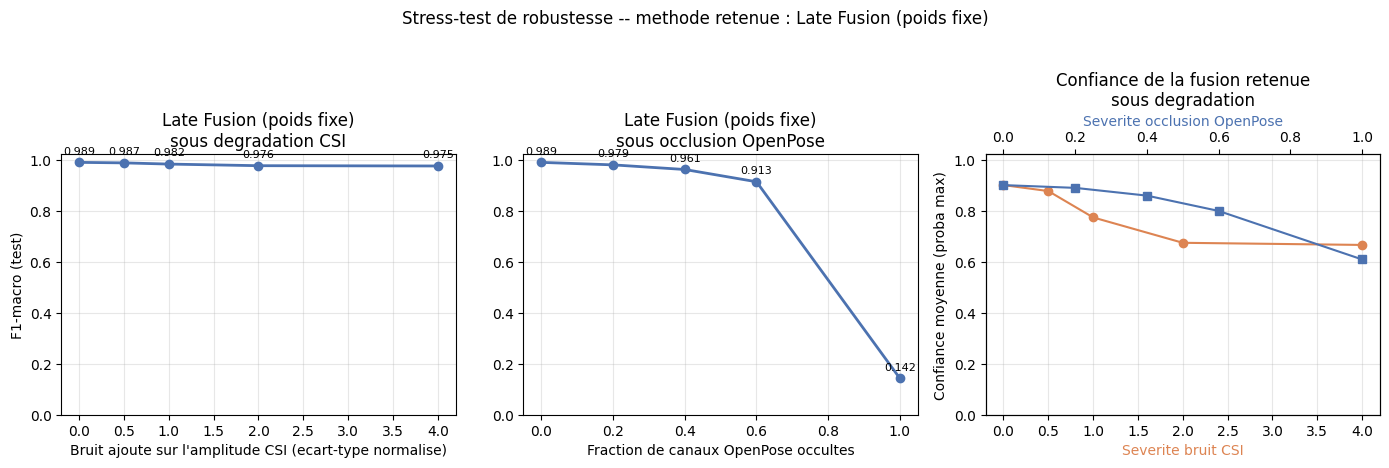

Figure sauvegardee : /kaggle/working/robustness_stress_test_best_method.png


In [45]:
# --- Figure robustness_stress_test.png -- UNIQUEMENT la methode retenue (Late Fusion, poids fixe) ---
assert "df_csi_degrade" in globals() and "df_op_degrade" in globals(), \
    "Executez d'abord la Partie 6 (balayages bruit CSI / occlusion OpenPose) avant cette cellule."

BEST_METHOD = "Late Fusion (poids fixe)"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(df_csi_degrade["Bruit CSI (std)"], df_csi_degrade[BEST_METHOD],
             marker="o", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("Bruit ajoute sur l'amplitude CSI (ecart-type normalise)")
axes[0].set_ylabel("F1-macro (test)")
axes[0].set_title(f"{BEST_METHOD}\nsous degradation CSI")
axes[0].set_ylim(0, 1.02); axes[0].grid(alpha=0.3)
for x, y in zip(df_csi_degrade["Bruit CSI (std)"], df_csi_degrade[BEST_METHOD]):
    axes[0].annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, ha="center")

axes[1].plot(df_op_degrade["Occlusion OpenPose (frac)"], df_op_degrade[BEST_METHOD],
             marker="o", color="#4C72B0", linewidth=2)
axes[1].set_xlabel("Fraction de canaux OpenPose occultes")
axes[1].set_title(f"{BEST_METHOD}\nsous occlusion OpenPose")
axes[1].set_ylim(0, 1.02); axes[1].grid(alpha=0.3)
for x, y in zip(df_op_degrade["Occlusion OpenPose (frac)"], df_op_degrade[BEST_METHOD]):
    axes[1].annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, ha="center")

axes[2].plot(df_csi_degrade["Bruit CSI (std)"], df_csi_degrade["Confiance moyenne (fusion poids fixe)"],
             marker="o", color="#DD8452", label="Bruit CSI")
ax2b = axes[2].twiny()
ax2b.plot(df_op_degrade["Occlusion OpenPose (frac)"], df_op_degrade["Confiance moyenne (fusion poids fixe)"],
          marker="s", color="#4C72B0", label="Occlusion OpenPose")
axes[2].set_xlabel("Severite bruit CSI", color="#DD8452")
ax2b.set_xlabel("Severite occlusion OpenPose", color="#4C72B0")
axes[2].set_ylabel("Confiance moyenne (proba max)")
axes[2].set_title("Confiance de la fusion retenue\nsous degradation")
axes[2].set_ylim(0, 1.02); axes[2].grid(alpha=0.3)

plt.suptitle(f"Stress-test de robustesse -- methode retenue : {BEST_METHOD}", y=1.03)
plt.tight_layout()
plt.savefig(OUT_DIR / "robustness_stress_test_best_method.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardee :", OUT_DIR / "robustness_stress_test_best_method.png")